# SVD Recommendation on MovieLens 100K: Hyperparameter Tuning and Evaluation

**Author:** Albert Kabore (report sections *Hyperparameter Tuning* and *Final Model Evaluation*)

This notebook presents the methods, results, and visualizations supporting the Hyperparameter Tuning and Final Model Evaluation sections. Bullet-point observations explain the findings and their limitations.

| Assignment requirement | Analysis | Visualizations |
|---|---|---|
| Experiment with `n_factors`, `n_epochs`, `lr_all` | 1.2 to 1.4 | V1 to V6 |
| Use `GridSearchCV` with the given `param_grid` | 1.2 (assignment grid, exactly as specified) | V1, V2 |
| Show the tuning improved the model | 1.5 | V7 |
| Evaluate the optimized model on the test set with RMSE **and** MAE | 2.1 | V8 |
| Compare predictions with actual ratings | 2.2 | V9 to V11 |
| Discuss where errors are larger and areas for improvement | 2.3 to 2.5 | V12, V13 |
| Held-out ranking metrics and catalog exposure | 2.6, 2.7 | V14 to V16 |
| Validity of the evaluation itself | 2.8 | V17 |

**How it relates to the pipeline.** The group's full pipeline (`run_all.py`, driven by `part2_colab.ipynb`) writes every reportable number to `results/`. This notebook recomputes the tuning and evaluation results **in memory** from the same frozen split and seed. It prints each result next to the committed value (`OK` or `DIFF`) and writes nothing to `results/` or `figures/`, so the saved outputs remain available as the common reference for the report.

**Figures visible before running.** The six committed report figures (`figures/*.png`) are embedded in the markdown cells labeled *Report figure*, so they display as soon as the notebook opens. The V1 to V17 charts are drawn when the code runs.

**Runtime.** About 4 to 7 minutes on Colab's CPU, mostly the 81-candidate refined grid. Set `RUN_FULL_SEARCH = False` in cell 0.2 to load the saved expanded and refined search surfaces. The eight-candidate assignment search still runs. Runtime depends on the environment.


## Study Roadmap and Report Requirements

**Hyperparameter Tuning** (report note)

| Requirement | Notebook location |
|---|---|
| GridSearchCV uses only the training partition | 1.1 (`data_surprise` = 80,000 training ratings) |
| The same three folds for all searches | 1.1 (`cv_splitter(3)`, seeded KFold used by every search) |
| Give the assignment grid exactly as specified | 1.1 (snippet quoted), 1.2 (grid run verbatim), V1, V2 |
| Summarize the 8, 54, and 81 candidate searches | 1.2 to 1.4, 1.5 summary, 1.6 Report Table X, V7 |
| The selected settings | 1.5 (`TUNED`, asserted against `tuning_selected.json`) |
| Regularization shows the largest sensitivity in the expanded and refined grids | 1.3, 1.4, 1.6 facts, V3 to V5 |
| The selected model still reaches three grid boundaries | 1.4 edge check, 1.6, V6 |
| Describe it as the best configuration tested | Captions to V5, V6 and 1.6 |
| Use `tuning_*.json` and `tuning_surface_*.csv` | `check()` calls against every `tuning_*.json`; 1.6 matches every candidate in every `tuning_surface_*.csv` |

**Final Model Evaluation** (report note)

| Requirement | Notebook location |
|---|---|
| Compare tuned and default RMSE and MAE | 2.1, V8, 2.9 Report Table X |
| A CV standard deviation is not a significance test for test improvement | Markdown after 2.1, V8b legend |
| Actual versus predicted ratings | 2.2, V9 to V11, committed report figure in 2.9 |
| Where errors are larger | 2.3 (users and movies by training volume), 2.4 (largest misses), V12, V13 |
| Lower precision and recall | 2.6, V14, V15 |
| Held-out rated-item candidate set and predicted-rating cutoff of 4 | 2.6 protocol and code comments |
| Distinguish those metrics from the full-catalog lists | 2.7, V16 |
| Per-user chronology still allows later ratings from other users | 2.8 (future-information share), V17b |
| The global split contains many unseen users | 2.8 (new-user share, returning vs new RMSE), V17b, V17c |
| Use `final_evaluation.json`, `final_*.csv`, and `temporal_summary.json` | `check()` calls in 2.1 to 2.8; 2.9 checks every `final_*.csv` used |
| Numerical claims checked against the report | 3.1 claim audit |


In [ ]:
# 0.1  Environment. In Colab this clones the repo and installs Surprise; locally it
#      assumes the notebook was opened from the repo's notebooks/ folder.
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/jecollier041/phdai_732_gp_movielens.git"

if IN_COLAB:
    repo_dir = Path("/content") / REPO.rstrip("/").split("/")[-1].removesuffix(".git")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "-q", REPO, str(repo_dir)], check=True)
    # If `import surprise` later fails on NumPy, run:
    #   !pip install -q "numpy<2" scikit-surprise   then Runtime > Restart session.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-surprise"], check=True)
    os.chdir(repo_dir)
elif Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

In [ ]:
# 0.2  Imports, settings, and small plotting helpers.
#
# What this cell does
#   * Imports Surprise (Hug, 2020): SVD is the matrix-factorization model, GridSearchCV
#     runs the hyperparameter search, and `accuracy` computes RMSE and MAE.
#   * Imports the group's shared modules from src/ so this notebook uses exactly the same
#     seed (42), split, fold generator, and model constructors as run_all.py:
#       config      seed, grids, relevance threshold (4), k (10), thin-evidence cutoff (10)
#       data        downloads MovieLens 100K and verifies its SHA-256 fingerprint
#       splits      reads the frozen train/test assignments from results/split_*.csv
#       models      Surprise adapters, seeded KFold (cv_splitter), make_svd, make_baseline
#       evaluation  precision@k / recall@k and full-catalog top-N scoring (pure functions)
#       plotting    the report's colors, so notebook charts match the report figures
#   * Defines check(), which prints OK or DIFF when a recomputed number is compared with
#     the value committed in results/. A DIFF means a different Surprise/NumPy build or a
#     changed input, and the committed value is the one the report cites.
import json
import numpy as np
import pandas as pd
import surprise
from surprise import SVD, accuracy
from surprise.model_selection import GridSearchCV

from src import config as C
from src.data import load_data
from src.splits import make_split, train_test, describe_split
from src.models import (to_dataset, to_trainset, to_testset, predictions_frame,
                        cv_splitter, make_svd, make_baseline)
from src.evaluation import precision_recall_at_k, score_matrix, top_n_from_scores
from src.plotting import BLUE, ORANGE, AQUA, INK_2   # the report's figure style and colors

import matplotlib.pyplot as plt
%matplotlib inline

# Settings you may change.
RUN_FULL_SEARCH = True     # False = load the committed expanded/refined surfaces instead of re-searching
TOL = 1e-3                 # tolerance when checking recomputed numbers against results/

RES = C.RESULTS_DIR                                        # committed results folder (read only here)
saved = lambda name: json.loads((RES / name).read_text())  # read one committed JSON result
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))     # RMSE of an array of errors (pred - true)

def check(label, recomputed, committed, tol=TOL):
    ok = abs(recomputed - committed) <= tol
    print(f"{'OK  ' if ok else 'DIFF'} {label:<46} recomputed {recomputed:.4f} | committed {committed:.4f}")
    return ok

# Two annotation helpers: every chart prints its values so it can be read without the table.
def label_points(ax, xs, ys, fmt="{:.4f}", dy=7, **kw):
    for x, y in zip(xs, ys):
        ax.annotate(fmt.format(y), (x, y), xytext=(0, dy), textcoords="offset points",
                    ha="center", fontsize=8, color=INK_2, **kw)

def label_bars(ax, bars, fmt="{:.3f}", horizontal=False):
    for b in bars:
        if horizontal:
            ax.annotate(fmt.format(b.get_width()), (b.get_width(), b.get_y() + b.get_height() / 2),
                        xytext=(3, 0), textcoords="offset points", va="center", fontsize=8, color=INK_2)
        else:
            ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_height()),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=INK_2)

pd.set_option("display.precision", 4)
print("surprise", surprise.__version__, "| numpy", np.__version__, "| pandas", pd.__version__, "| seed", C.SEED)

In [ ]:
# 0.3  Data and the frozen 80/20 split. load_data() verifies the SHA-256 fingerprint of
#      u.data; make_split() reads the committed assignment in results/split_random.csv,
#      so every model here sees exactly the same 80,000 training and 20,000 test ratings.
#
# load_data(write_log=False) returns (ratings, users, items, log) and refuses to continue if the
# counts (100,000 / 943 / 1,682) or the fingerprint differ from the published dataset.
# write_log=False keeps results/data_log.json untouched.
ratings, users, items, _ = load_data(write_log=False)

# "train"/"test" label for each of the 100,000 rows, read from results/split_random.csv
# (seed 42, 80/20). Reading the frozen file, not re-drawing the split, guarantees the same rows.
assignment = make_split(ratings, "random")
train_df, test_df = train_test(ratings, assignment)

# Lookups used throughout Section 2.
titles = items.set_index(C.ITEM)["title"]                              # movie id -> title
u_n = train_df.groupby(C.USER).size().rename("user_train_ratings")   # ratings per user in training
i_n = train_df.groupby(C.ITEM).size().rename("item_train_ratings")   # ratings per movie in training
print(f"ratings {len(ratings):,} | training partition {len(train_df):,} | test set {len(test_df):,}")

## 1. Hyperparameter Tuning

### 1.1 Experimental Design and Test-Set Protection

The assignment specifies the following search:

```python
from surprise.model_selection import GridSearchCV
param_grid = {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
grid_search.fit(data_surprise)
```

This notebook preserves the assignment grid and makes the evaluation reproducible:

- **Training data only:** `data_surprise` contains the 80,000 training ratings. The 20,000 test ratings are excluded from hyperparameter selection.
- **Identical validation folds:** Each search uses `KFold(3, shuffle=True, random_state=42)`, so every candidate is evaluated on the same three folds.
- **Consistent model initialization:** Each SVD model uses `random_state=42`.
- **Selection criterion:** Both RMSE and MAE are recorded, but the configuration with the lowest mean CV RMSE is selected.

Using the full dataset in `grid_search.fit()` would allow test ratings to influence model selection. Restricting the search to the training partition prevents that leakage.


In [ ]:
# 1.1  One helper runs every search the same way; three helpers draw its results.
#
# data_surprise holds ONLY the 80,000 training ratings. GridSearchCV splits it into 3 folds,
# trains each candidate on 2 folds and scores it on the third, three times, and averages.
# The 20,000 test ratings are never seen here.
data_surprise = to_dataset(train_df)          # training partition only

def run_search(param_grid):
    '''Run GridSearchCV over SVD and return one row per candidate, best first.

    random_state=[42] is added to the grid so every candidate SVD starts from the same random
    initialization; cv_splitter(3) is KFold(3, shuffle=True, random_state=42), so every search
    (and every candidate) is scored on the SAME three folds. n_jobs=-1 uses all CPU cores.
    Columns returned: the hyperparameters, cv_rmse (mean over folds), cv_rmse_sd (SD over
    folds), cv_mae.
    '''
    gs = GridSearchCV(SVD, {**param_grid, "random_state": [C.SEED]},
                      measures=["rmse", "mae"], cv=cv_splitter(C.TUNE_CV_FOLDS), n_jobs=-1)
    gs.fit(data_surprise)
    r = gs.cv_results
    surface = pd.DataFrame({k.replace("param_", ""): r[k] for k in r
                            if k.startswith("param_") and k != "param_random_state"})
    surface["cv_rmse"], surface["cv_rmse_sd"] = r["mean_test_rmse"], r["std_test_rmse"]
    surface["cv_mae"] = r["mean_test_mae"]
    return surface.sort_values("cv_rmse").reset_index(drop=True)

def load_surface(label):
    '''Committed search results (results/tuning_surface_<label>.csv), renamed to run_search's columns.'''
    ren = {"mean_test_rmse": "cv_rmse", "std_test_rmse": "cv_rmse_sd", "mean_test_mae": "cv_mae"}
    s = pd.read_csv(RES / f"tuning_surface_{label}.csv")
    return s.rename(columns=lambda c: ren.get(c, c.replace("param_", "")))

def plain(best, grid):
    '''{name: value} for a best row, as plain int/float instead of numpy scalars.'''
    return {p: (int(best[p]) if p in ("n_factors", "n_epochs") else float(best[p])) for p in grid}

def describe_search(surface, param_grid):
    '''Best row, which hyperparameters the winner has at a grid edge, and sensitivity.

    Edge: if the best value is the largest or smallest value searched, the true optimum may lie
    outside the grid. Sensitivity of a hyperparameter: average CV RMSE at each of its values
    (averaging over all other settings), then max minus min. A large range = the knob matters.
    '''
    best = surface.iloc[0]
    edges = {p: ("upper" if best[p] == max(v) else "lower")
             for p, v in param_grid.items() if len(v) > 1 and best[p] in (max(v), min(v))}
    means = {p: surface.groupby(p)["cv_rmse"].mean() for p in param_grid}
    sens = {p: float(m.max() - m.min()) for p, m in means.items()}
    return best, edges, dict(sorted(sens.items(), key=lambda kv: -kv[1]))

def sensitivity_panels(surface, param_grid, title):
    # One panel per hyperparameter: mean CV RMSE at each value (dot), best to worst (bar).
    fig, axes = plt.subplots(1, len(param_grid), figsize=(3.1 * len(param_grid), 3.1), sharey=True)
    for ax, p in zip(axes, param_grid):
        g = surface.groupby(p)["cv_rmse"].agg(["mean", "min", "max"])
        x = np.arange(len(g))
        ax.vlines(x, g["min"], g["max"], color=BLUE, alpha=0.3, lw=7)
        ax.plot(x, g["mean"], marker="o", color=BLUE)
        ax.set_xticks(x, [f"{v:g}" for v in g.index])
        ax.set_title(f"{p}\nrange of means {g['mean'].max() - g['mean'].min():.4f}", fontsize=9)
        ax.grid(axis="x", visible=False)
    axes[0].set_ylabel("3-fold CV RMSE (lower is better)")
    fig.suptitle(title + "   (dot = mean over the other settings, bar = best to worst)", fontsize=10, y=1.04)
    plt.show()

def heatmap(ax, surface, row, col, title):
    # Best CV RMSE for each (row, col) pair, taking the best over all other hyperparameters.
    # Darker = lower (better) CV RMSE; the best cell is labelled. This shows interactions that
    # the one-at-a-time sensitivity panels average away.
    t = surface.groupby([row, col])["cv_rmse"].min().unstack(col)
    ax.imshow(t.to_numpy(), cmap="Blues_r", aspect="auto")
    ax.set_xticks(range(t.shape[1]), [f"{v:g}" for v in t.columns])
    ax.set_yticks(range(t.shape[0]), [f"{v:g}" for v in t.index])
    ax.set(xlabel=col, ylabel=row, title=title)
    ax.grid(False)
    mid = np.nanmean(t.to_numpy())
    best = np.unravel_index(np.nanargmin(t.to_numpy()), t.shape)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            v = t.iat[i, j]
            ax.text(j, i, f"{v:.4f}" + ("\n(best)" if (i, j) == best else ""), ha="center", va="center",
                    fontsize=8, color="white" if v < mid else "black",
                    fontweight="bold" if (i, j) == best else "normal")

### 1.2 Assignment Grid: Baseline Search across Eight Configurations

The assignment grid combines two values each for `n_factors`, `n_epochs`, and `lr_all`, producing eight candidates. Regularization remains fixed at Surprise's default, `reg_all = 0.02`.

The default SVD configuration (100 factors, 20 epochs, a learning rate of 0.005, and regularization of 0.02) is included. Its CV score provides a reference evaluated on the same folds as the other candidates.


In [ ]:
# The assignment's param_grid, copied exactly. reg_all is not listed, so Surprise uses 0.02.
param_grid = {'n_factors': [50, 100], 'n_epochs': [20, 40], 'lr_all': [0.002, 0.005]}

# Equivalent to the assignment's
#   grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3); grid_search.fit(data_surprise)
# with seeded folds, MAE also recorded, and data_surprise = training partition only.
surf_assign = run_search(param_grid)          # 2 x 2 x 2 = 8 candidates x 3 folds = 24 fits
best_a, edges_a, sens_a = describe_search(surf_assign, param_grid)

# Surprise's default SVD (100 factors, 20 epochs, lr 0.005, reg 0.02) is one of the 8 rows, so its
# CV RMSE on these same folds is the fair "untuned" reference for every search below.
is_default = (surf_assign.n_factors == 100) & (surf_assign.n_epochs == 20) & (surf_assign.lr_all == 0.005)
default_cv = float(surf_assign.loc[is_default, "cv_rmse"].iloc[0])

display(surf_assign)
print("Best:", plain(best_a, param_grid), f"CV RMSE {best_a.cv_rmse:.4f}")
print(f"Untuned SVD defaults on the same folds: CV RMSE {default_cv:.4f}  (improvement {default_cv - best_a.cv_rmse:.4f})")
print("Winner on a grid edge:", edges_a)
print("Sensitivity:", {k: round(v, 4) for k, v in sens_a.items()})

ref = saved("tuning_assignment.json")
check("assignment grid best CV RMSE", best_a.cv_rmse, ref["best_cv_rmse"])
check("untuned defaults CV RMSE (same folds)", default_cv, ref["default_config_cv_rmse"])

In [ ]:
# V1  Every candidate in the assignment grid, ranked, with fold-to-fold SD.
#     Dot = mean CV RMSE over the 3 folds; whiskers = +/- 1 SD across folds. Orange = defaults.
#     Whiskers describe fold variability; overlap is not a significance test.
s = surf_assign.sort_values("cv_rmse").reset_index(drop=True)
dflt = ((s.n_factors == 100) & (s.n_epochs == 20) & (s.lr_all == 0.005)).to_numpy()
labels = [f"{int(r.n_factors)} factors, {int(r.n_epochs)} epochs, lr {r.lr_all:g}" for r in s.itertuples()]

fig, ax = plt.subplots(figsize=(8, 3.8))
for i, r in s.iterrows():
    ax.errorbar(r.cv_rmse, i, xerr=r.cv_rmse_sd, fmt="o", ms=7, capsize=3,
                color=ORANGE if dflt[i] else BLUE)
    ax.annotate(f"{r.cv_rmse:.4f}", (r.cv_rmse, i), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=8, color=INK_2)
ax.set_yticks(range(len(s)), labels); ax.invert_yaxis()
ax.set(xlabel="3-fold CV RMSE on the training partition (lower is better)",
       title="V1. Assignment grid: all 8 candidates (orange = Surprise's defaults)")
ax.grid(axis="y", visible=False)
plt.show()

#### Observations: V1 and V2: Assignment Grid

- The best candidate uses 50 factors, 20 epochs, and a learning rate of 0.005, with regularization fixed at 0.02.
- Its mean CV RMSE is 0.9502, compared with 0.9534 for the default configuration: a reduction of 0.0032.
- Averaged over the other settings, the higher value of each searched parameter increases CV RMSE. These averages do not imply that every individual combination follows the same pattern.
- The results are consistent with overfitting in some configurations, but validation scores alone do not establish the cause.
- The error bars show variation across validation folds. Their overlap is not a significance test.


In [ ]:
# V2  Which of the three assignment hyperparameters moved CV RMSE.
#     Each panel averages over the other two hyperparameters; the title gives the range of means.
sensitivity_panels(surf_assign, param_grid, "V2. Assignment grid sensitivity")

#### Report Figure: Sensitivity of Cross-Validated RMSE to Each Hyperparameter in the Assignment Grid

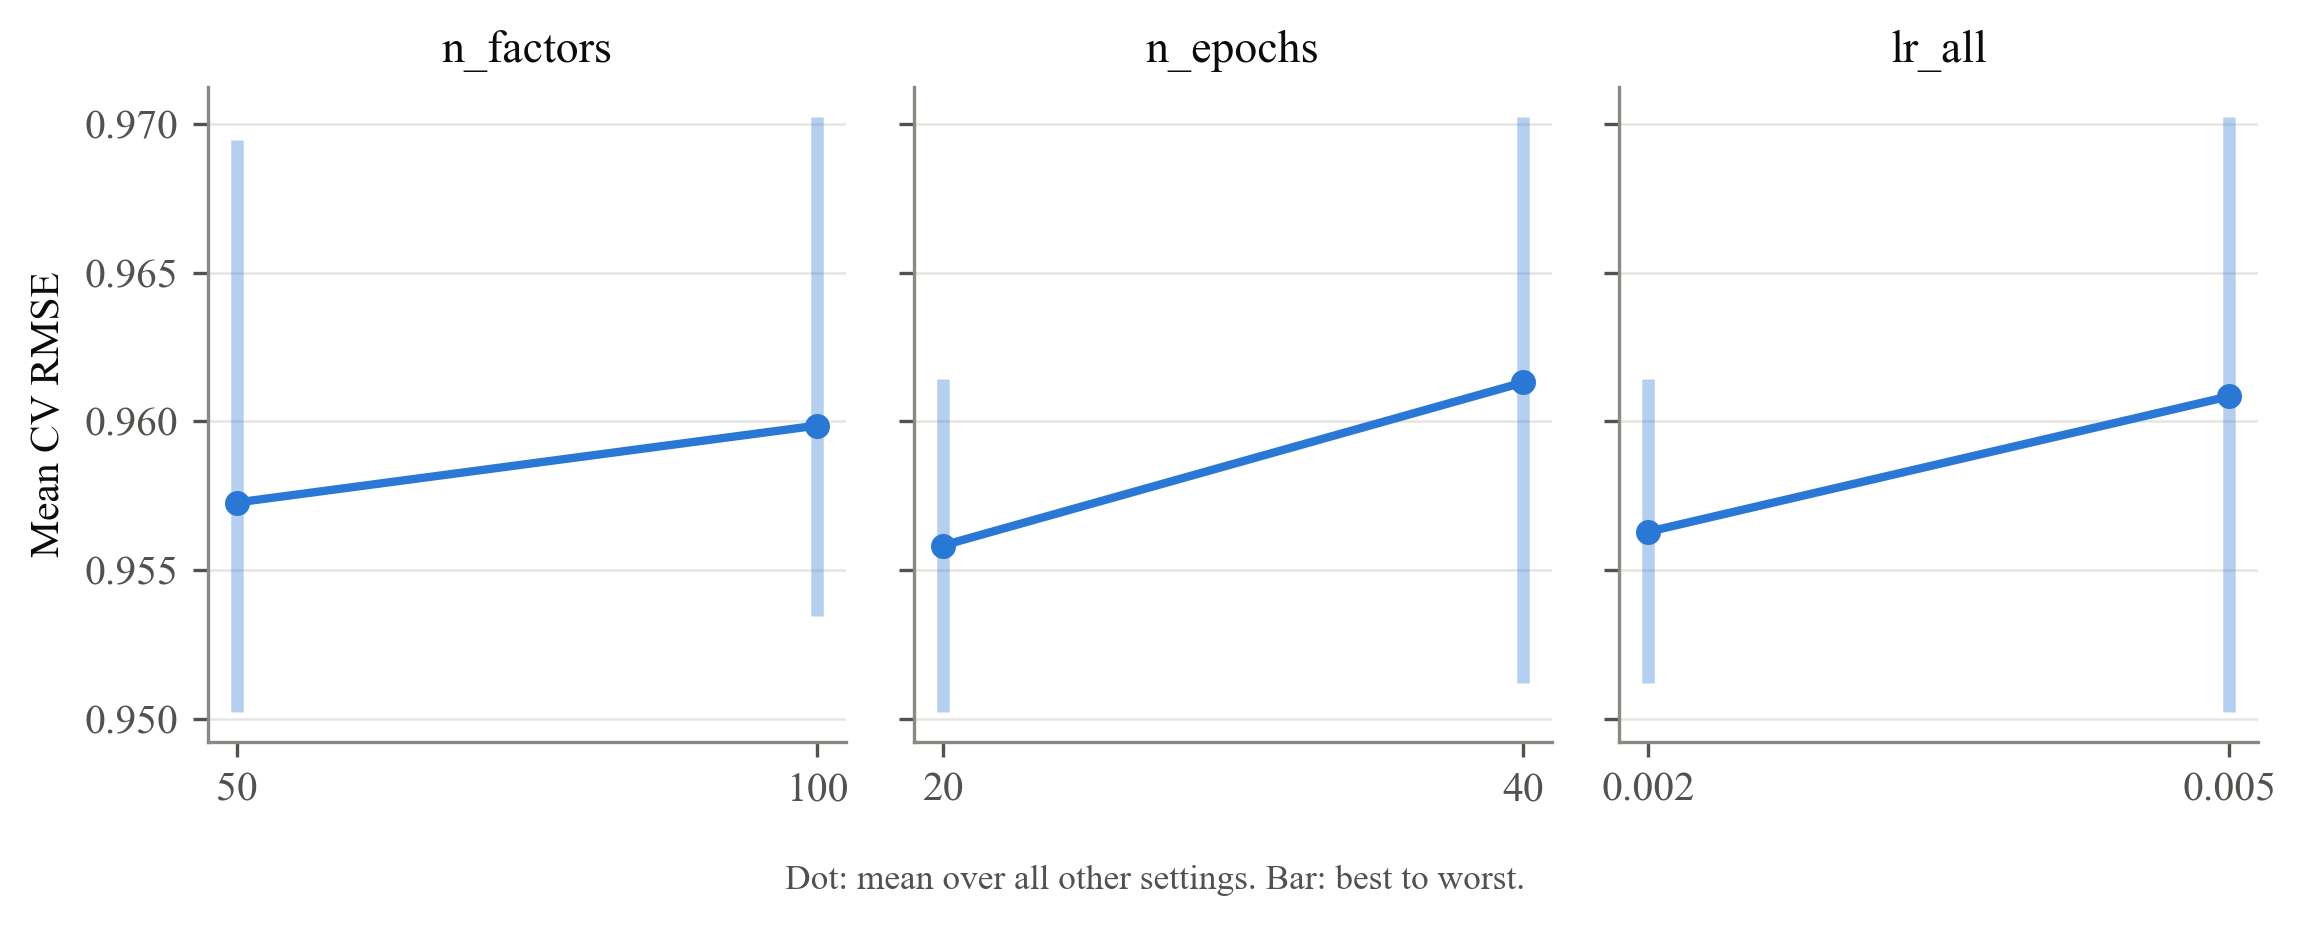

#### Observations

- Dots show mean CV RMSE at each parameter value, averaged over the remaining settings. Bars show the range across candidates.
- Regularization is fixed at 0.02.
- Increasing the factor count raises mean CV RMSE from 0.9573 to 0.9599; increasing epochs raises it from 0.9558 to 0.9613; increasing the learning rate raises it from 0.9563 to 0.9608.

Source: `figures/tuning_sensitivity_assignment.png`.


### 1.3 Expanded Grid: Regularization and Parameter Interactions

The expanded grid varies `reg_all` and increases the ranges of the factor count and learning rate. It retains the two epoch values from the assignment grid. The resulting 54 candidates test whether additional regularization improves performance and changes the effects of the other parameters.


In [ ]:
# Expanded grid from src/config.py: 3 factors x 2 epochs x 3 learning rates x 3 regularizations
# = 54 candidates x 3 folds = 162 fits, on the same folds as the assignment grid.
EXPANDED = C.EXPANDED_GRID
print(EXPANDED)
surf_exp = run_search(EXPANDED) if RUN_FULL_SEARCH else load_surface("expanded")
best_e, edges_e, sens_e = describe_search(surf_exp, EXPANDED)

display(surf_exp.head(10))
print("Best:", plain(best_e, EXPANDED), f"CV RMSE {best_e.cv_rmse:.4f}")
print("Winner on a grid edge:", edges_e, "-> the optimum may lie outside this grid")
print("Sensitivity:", {k: round(v, 4) for k, v in sens_e.items()})
check("expanded grid best CV RMSE", best_e.cv_rmse, saved("tuning_expanded.json")["best_cv_rmse"])

In [ ]:
# V3  Report figure (committed copy: figures/tuning_sensitivity_expanded.png).
#     A flat line = that hyperparameter barely matters across the values searched.
sensitivity_panels(surf_exp, EXPANDED, "V3. Expanded grid sensitivity")

#### Report Figure: Sensitivity of Cross-Validated RMSE to Each SVD Hyperparameter in the Expanded Grid

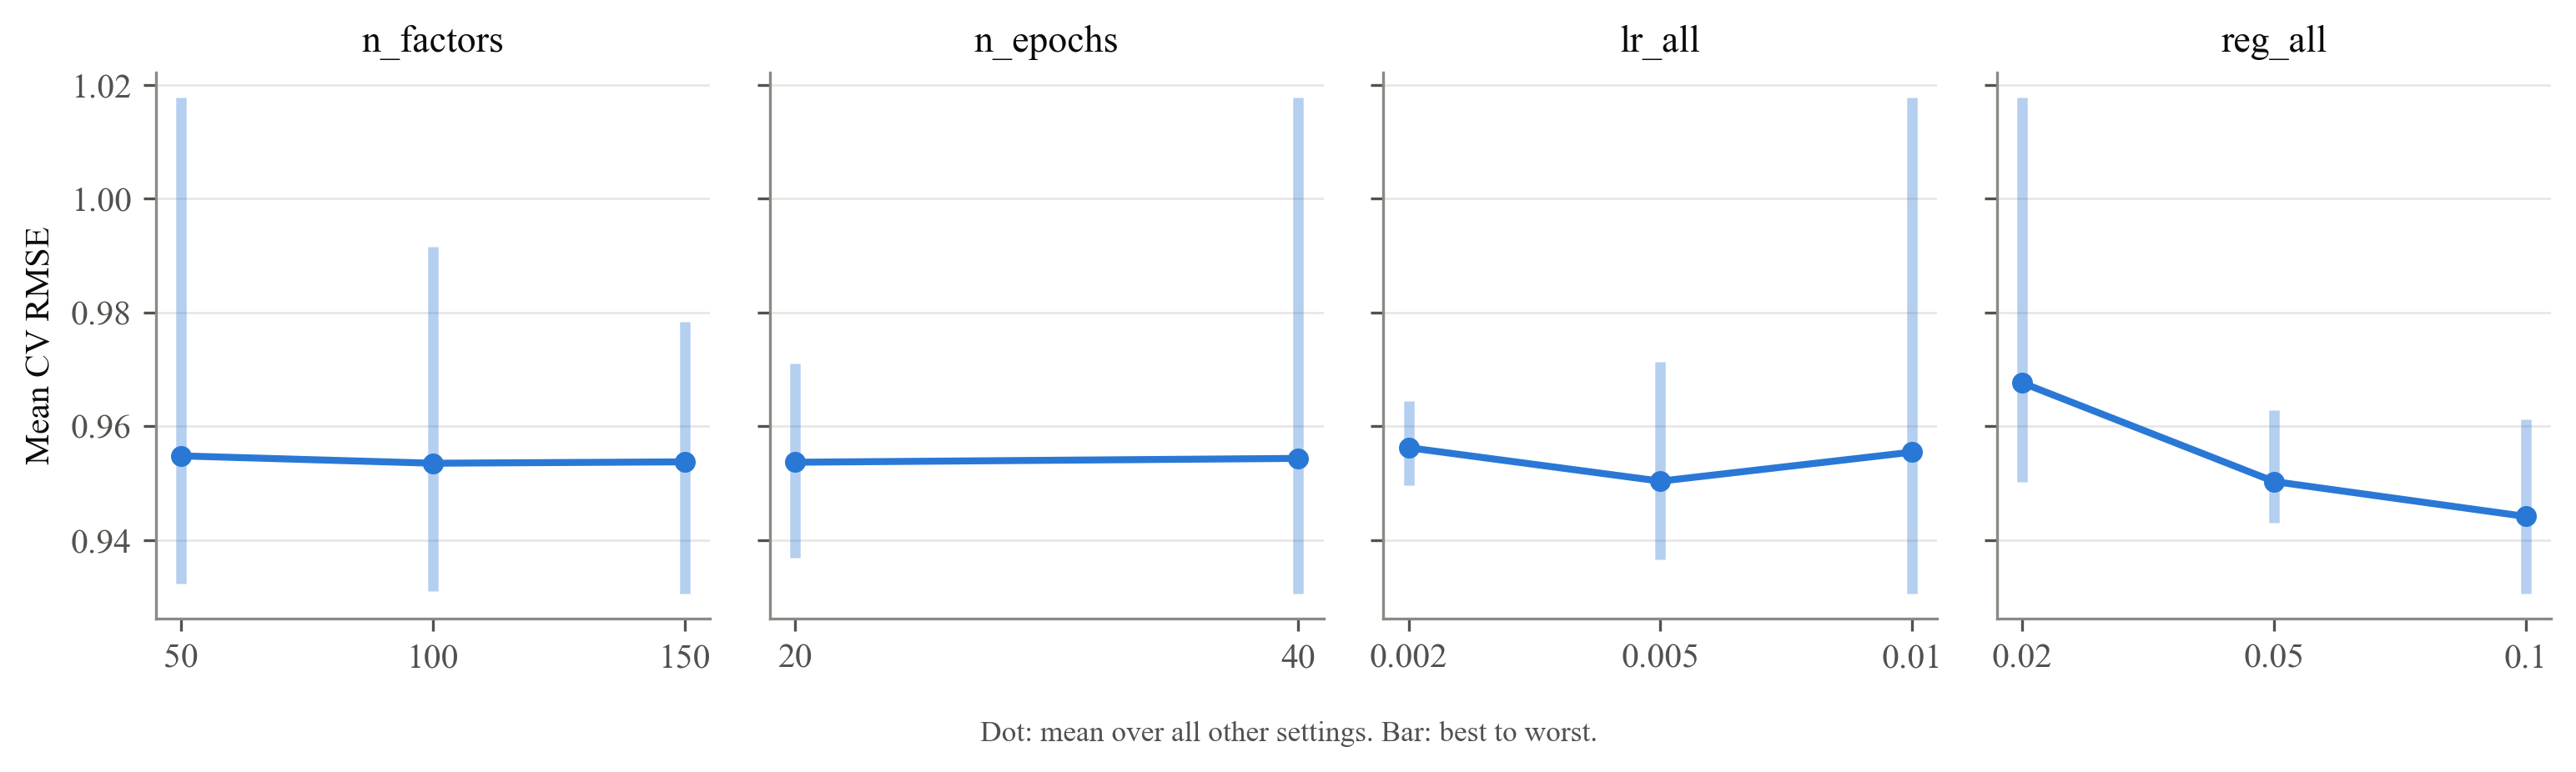

#### Observations

- Regularization produces the largest change in mean CV RMSE across its tested values.
- Mean CV RMSE decreases from approximately 0.968 at regularization 0.02 to 0.944 at regularization 0.1.
- The range is 0.0235 for regularization, compared with 0.0059 for the learning rate.

Source: `figures/tuning_sensitivity_expanded.png`.


In [ ]:
# V4  Interactions: regularization against learning rate and against epochs.
#     Each cell is the best CV RMSE among candidates with that pair of values.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
heatmap(axes[0], surf_exp, "reg_all", "lr_all", "V4a. Best CV RMSE: reg_all x lr_all")
heatmap(axes[1], surf_exp, "reg_all", "n_epochs", "V4b. Best CV RMSE: reg_all x n_epochs")
plt.tight_layout(); plt.show()

#### Observations: V3 and V4: Expanded Grid

- Regularization has the largest sensitivity across the tested values. Its range of mean CV RMSE is 0.0235, compared with 0.0059 for the learning rate.
- The heatmaps show that the effects of learning rate and training duration depend on regularization. Each heatmap cell reports the best score over the remaining parameters.
- The best configuration uses 150 factors, 40 epochs, a learning rate of 0.01, and regularization of 0.1. Its mean CV RMSE is 0.9306.
- All four selected values lie at the upper boundaries of the expanded grid. This motivates testing values beyond those boundaries.
- Because the expanded grid changes several parameters, the total improvement cannot be attributed solely to regularization.


### 1.4 Refined Grid: Local Sensitivity and Search Boundaries

The refined grid tests three values for each of the four hyperparameters. It includes the expanded-grid winner and extends each parameter beyond that winner. All 81 candidates use the same three training folds.


In [ ]:
# Refined grid: every axis extended past the expanded winner (150 factors, 40 epochs, lr .01,
# reg .1). 3 x 3 x 3 x 3 = 81 candidates x 3 folds = 243 fits. It includes the expanded winner,
# so its best score can only match or beat it on these folds.
REFINED = C.REFINED_GRID
print(REFINED)
surf_ref = run_search(REFINED) if RUN_FULL_SEARCH else load_surface("refined")
best_r, edges_r, sens_r = describe_search(surf_ref, REFINED)

display(surf_ref.head(10))
print("Best:", plain(best_r, REFINED), f"CV RMSE {best_r.cv_rmse:.4f} (fold SD {best_r.cv_rmse_sd:.4f})")
print("Winner on a grid edge:", edges_r)
print(f"Top 10 candidates lie within {surf_ref.cv_rmse.iloc[9] - surf_ref.cv_rmse.iloc[0]:.4f} CV RMSE of each other")
print("Sensitivity:", {k: round(v, 4) for k, v in sens_r.items()})
check("refined grid best CV RMSE", best_r.cv_rmse, saved("tuning_refined.json")["best_cv_rmse"])

In [ ]:
# V5  Refined grid: sensitivity (V5a) and the two interactions with regularization (V5b, V5c).
sensitivity_panels(surf_ref, REFINED, "V5a. Refined grid sensitivity")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
heatmap(axes[0], surf_ref, "reg_all", "n_epochs", "V5b. Best CV RMSE: reg_all x n_epochs")
heatmap(axes[1], surf_ref, "reg_all", "n_factors", "V5c. Best CV RMSE: reg_all x n_factors")
plt.tight_layout(); plt.show()

#### Report Figure: Sensitivity of Cross-Validated RMSE to Each SVD Hyperparameter in the Refined Grid

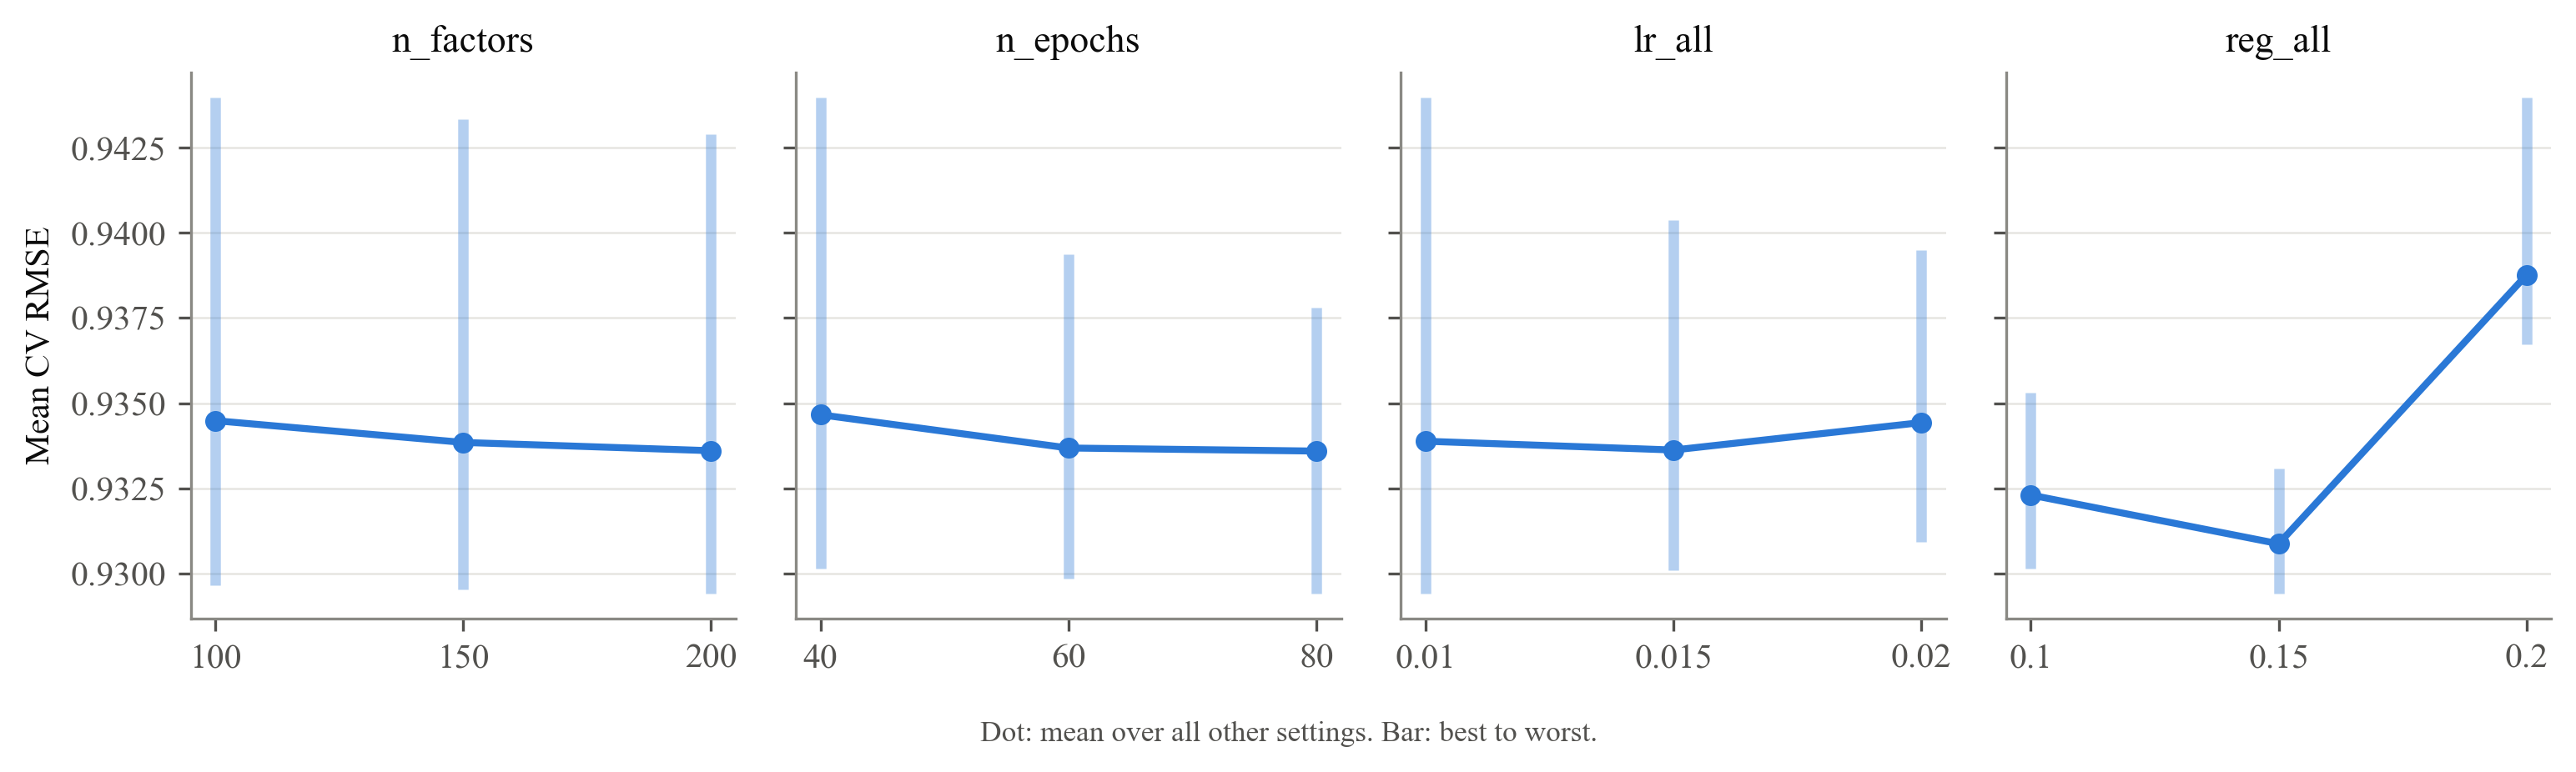

#### Observations

- Mean CV RMSE across regularization values follows a U-shaped pattern: 0.9323 at 0.1, 0.9309 at 0.15, and 0.9388 at 0.2.
- The other parameter averages vary less within the tested ranges.
- The selected configuration still reaches three grid boundaries; these plots do not establish performance beyond them.

Source: `figures/tuning_sensitivity_refined.png`.


In [ ]:
# V6  Is the top of the refined surface a plateau? Top 15 candidates with fold SD.
#     Fold SDs describe variability, not uncertainty in paired candidate differences.
#     Similar observed scores do not establish what a search beyond the grid would find.
top = surf_ref.head(15).reset_index(drop=True)
lab = [f"{int(r.n_factors)}f, {int(r.n_epochs)}ep, lr {r.lr_all:g}, reg {r.reg_all:g}" for r in top.itertuples()]
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.errorbar(top.cv_rmse, range(len(top)), xerr=top.cv_rmse_sd, fmt="o", color=BLUE, capsize=3)
ax.errorbar(top.cv_rmse[:1], [0], xerr=top.cv_rmse_sd[:1], fmt="o", color=ORANGE, capsize=3, ms=8)
ax.axvspan(top.cv_rmse[0], top.cv_rmse[0] + 0.0008, color=AQUA, alpha=0.15, label="within 0.0008 of best")
ax.set_yticks(range(len(top)), lab, fontsize=8); ax.invert_yaxis()
ax.set(xlabel="3-fold CV RMSE", title="V6. Refined grid: 15 best candidates (orange = selected)")
ax.legend(loc="upper right"); ax.grid(axis="y", visible=False)
plt.show()

#### Observations: V5 and V6: Refined Grid

- Regularization again has the largest sensitivity: 0.0079 in mean CV RMSE, compared with 0.0011 or less for each other parameter.
- Regularization of 0.15 gives the lowest CV RMSE in 24 of the 27 combinations of the other settings. Regularization of 0.1 wins in the remaining three.
- The selected configuration uses 200 factors, 80 epochs, a learning rate of 0.01, and regularization of 0.15. Its mean CV RMSE is 0.9294.
- The ten best candidates span approximately 0.0008 CV RMSE. These similar observed scores do not establish statistical equivalence.
- The winner reaches three boundaries: the highest factor count, the highest epoch count, and the lowest learning rate in this grid.
- This is the **best configuration tested**. Performance beyond the tested boundaries remains unknown.


In [ ]:
# 1.5  Summary across the three searches (same folds, so the CV scores are comparable).
#      The selected configuration is the lowest CV RMSE across ALL three grids. The test set plays
#      no part in this choice. The assert confirms it matches results/tuning_selected.json.
summary = pd.DataFrame([
    {"grid": g, "candidates": len(sf), "best CV RMSE": b.cv_rmse,
     "best settings": plain(b, pg), "on edge": ed, "most sensitive": next(iter(se))}
    for g, sf, b, pg, ed, se in (("assignment", surf_assign, best_a, param_grid, edges_a, sens_a),
                                 ("expanded", surf_exp, best_e, EXPANDED, edges_e, sens_e),
                                 ("refined", surf_ref, best_r, REFINED, edges_r, sens_r))])
display(summary)

selected = min([(best_a, param_grid), (best_e, EXPANDED), (best_r, REFINED)], key=lambda b: b[0].cv_rmse)
TUNED = plain(*selected)
print("Selected (lowest CV RMSE across all grids):", TUNED)
assert TUNED == saved("tuning_selected.json")["params"], "Selected configuration differs from results/tuning_selected.json"

In [ ]:
# V7  The whole search at a glance: every candidate per grid (V7a, jittered horizontally so dots
#     don't overlap), and the best CV RMSE reached after each search (V7b).
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.2, 1]})
rng = np.random.default_rng(C.SEED)
for k, (name, sf) in enumerate((("Assignment\n(8)", surf_assign), ("Expanded\n(54)", surf_exp),
                                ("Refined\n(81)", surf_ref))):
    axes[0].scatter(k + rng.uniform(-0.18, 0.18, len(sf)), sf.cv_rmse, s=14, alpha=0.55, color=BLUE)
    axes[0].scatter(k, sf.cv_rmse.min(), s=80, color=ORANGE, zorder=3)
axes[0].axhline(default_cv, ls="--", color=INK_2, lw=1)
axes[0].annotate(f"untuned defaults {default_cv:.4f}", (-0.45, default_cv), xytext=(0, 4),
                 textcoords="offset points", ha="left", fontsize=8, color=INK_2)
axes[0].set_xticks(range(3), ["Assignment\n(8)", "Expanded\n(54)", "Refined\n(81)"])
axes[0].set(ylabel="3-fold CV RMSE", title="V7a. Every candidate (orange = best of each grid)")
axes[0].grid(axis="x", visible=False)

path = [default_cv, best_a.cv_rmse, best_e.cv_rmse, best_r.cv_rmse]
axes[1].plot(range(4), path, marker="o", color=BLUE)
label_points(axes[1], range(4), path)
axes[1].set_xticks(range(4), ["Untuned\ndefaults", "Assignment", "Expanded", "Refined"])
axes[1].set_ylim(min(path) - 0.004, max(path) + 0.004)
axes[1].set(ylabel="Best 3-fold CV RMSE", title="V7b. Best CV RMSE after each search")
axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 1.5 Model Selection across the Three Searches

#### Observations: V7: Comparison of the Three Searches

- Mean CV RMSE decreases from 0.9534 for the defaults to 0.9502 for the assignment-grid winner, 0.9306 for the expanded-grid winner, and 0.9294 for the refined-grid winner.
- The largest improvement occurs between the assignment and expanded grids. Refinement provides a further reduction of approximately 0.0012.
- The three searches are directly comparable because they use the same training partition and validation folds.
- These three-fold CV scores should not be treated as equivalent to the five-fold CV scores in the model-selection table.
- The test set does not influence the selection of the final hyperparameters.


In [ ]:
# 1.6  Surface facts quoted in the report, the report's tuning table, and a candidate-by-candidate
#      check against the committed search surfaces (results/tuning_surface_*.csv).
from IPython.display import Image

# (a) Expanded grid: mean CV RMSE at each regularization value, averaged over all other settings.
reg_means = surf_exp.groupby("reg_all")["cv_rmse"].mean()
print("Expanded grid, mean CV RMSE by reg_all:", {f"{k:g}": round(v, 3) for k, v in reg_means.items()})

# (b) Refined grid: for each of the 27 combinations of the other three settings, which reg_all wins?
others = ["n_factors", "n_epochs", "lr_all"]
best_reg = surf_ref.loc[surf_ref.groupby(others)["cv_rmse"].idxmin(), "reg_all"]
print(f"Refined grid: reg_all = 0.15 is best in {(best_reg == 0.15).sum()} of {len(best_reg)} combinations of the other settings")

# (c) Refined grid: how the three best candidates differ (similar observed scores do not establish statistical equivalence).
top3 = surf_ref.head(3)
display(top3)
print("The three best refined candidates differ only in:", [p for p in REFINED if top3[p].nunique() > 1],
      f"| CV RMSE {top3.cv_rmse.min():.4f} to {top3.cv_rmse.max():.4f}")

# (d) Every recomputed candidate against the committed surface file.
grids = {"assignment": param_grid, "expanded": EXPANDED, "refined": REFINED}
for label, sf in (("assignment", surf_assign), ("expanded", surf_exp), ("refined", surf_ref)):
    committed = load_surface(label)
    m = sf.merge(committed, on=list(grids[label]), suffixes=("", "_committed"))
    diff = float((m.cv_rmse - m.cv_rmse_committed).abs().max())
    ok = len(m) == len(sf) == len(committed) and diff <= TOL
    print(f"{'OK  ' if ok else 'DIFF'} tuning_surface_{label}.csv: {len(m)}/{len(committed)} candidates matched, "
          f"max |CV RMSE difference| {diff:.1e}")

# (e) Report Table X: three grid searches on the same three training folds.
def values_searched(g, fixed_reg=False):
    txt = "; ".join(f"{k} {{{', '.join(f'{v:g}' for v in vals)}}}" for k, vals in g.items())
    return txt + ("; reg_all 0.02 (fixed)" if fixed_reg else "")

report_tuning = pd.DataFrame([
    {"Search": name, "Candidates": len(sf), "Values searched": values_searched(g, name == "Assignment"),
     "Best CV RMSE (fold SD)": f"{b.cv_rmse:.4f} ({b.cv_rmse_sd:.4f})",
     "Best setting": ", ".join(f"{v:g}" for v in plain(b, g).values()),
     "Winner on grid edge": ", ".join(f"{k} ({'high' if v == 'upper' else 'low'})" for k, v in ed.items())}
    for name, sf, b, g, ed in (("Assignment", surf_assign, best_a, param_grid, edges_a),
                               ("Expanded", surf_exp, best_e, EXPANDED, edges_e),
                               ("Refined", surf_ref, best_r, REFINED, edges_r))])
print("\nReport Table X. Three Grid Searches on the Same Three Training Folds")
display(report_tuning)
print(f"Note: Surprise's default SVD (100, 20, 0.005, 0.02) scored {default_cv:.4f} on the same folds.")

# (f) The committed report figure for this section, exactly as it appears in the paper.
print("\nReport Figure X (figures/tuning_sensitivity_expanded.png):")
display(Image(filename=str(C.FIGURES_DIR / "tuning_sensitivity_expanded.png"), width=950))

### 1.6 Sensitivity Summary and Search Verification

#### Observations: Supporting Tuning Results

- In the expanded grid, mean CV RMSE decreases from 0.968 at regularization 0.02 to 0.944 at regularization 0.1.
- In the refined grid, regularization 0.15 wins in 24 of 27 combinations of the remaining settings.
- The three highest-ranked refined candidates differ only in factor count; their mean CV RMSE ranges from 0.9294 to 0.9297.
- The table summarizes the candidate counts, searched values, selected settings, and grid boundaries.
- Candidate-level comparisons check the recomputed surfaces against the saved CSV files. When saved surfaces are loaded, these comparisons confirm consistency rather than independently reproducing the searches.


## 2. Final Model Evaluation

### 2.1 Rating Accuracy and Generalization

Each model is fitted on all 80,000 training ratings and evaluated on the same 20,000 held-out test ratings. Training RMSE is also calculated to describe the difference between training and test performance.

The comparison with the bias-only baseline measures the difference between the fitted models. It does not isolate the contribution of latent factors because the models also differ in fitting procedures and regularization.


In [ ]:
# 2.1  Final fit and single test-set evaluation.
#
# trainset      all 80,000 training ratings (no folds now; the model is trained on all of them)
# testset       the 20,000 held-out ratings as (user, movie, true rating) triples
# train_testset the training ratings in test format, to measure training error (overfitting check)
trainset, testset = to_trainset(train_df), to_testset(test_df)
train_testset = trainset.build_testset()

def fit_and_score(algo):
    '''Fit on the training partition, predict the test set once.

    Returns (fitted model, per-rating prediction frame with err = predicted - true,
    test RMSE, test MAE, training RMSE). RMSE squares errors, so it punishes big misses more;
    MAE is the average absolute miss in rating points.
    '''
    algo.fit(trainset)
    preds = algo.test(testset)
    frame = predictions_frame(preds).assign(err=lambda d: d.predicted - d.actual)
    return (algo, frame, accuracy.rmse(preds, verbose=False), accuracy.mae(preds, verbose=False),
            accuracy.rmse(algo.test(train_testset), verbose=False))

# Three models, identical data: bias-only (global mean + user bias + movie bias, no latent
# factors), SVD with Surprise defaults, and SVD with the selected hyperparameters.
baseline, f_base,    rmse_b, mae_b, tr_b = fit_and_score(make_baseline())
untuned,  f_untuned, rmse_u, mae_u, tr_u = fit_and_score(make_svd({}))      # Surprise defaults, seed 42
tuned,    f_tuned,   rmse_t, mae_t, tr_t = fit_and_score(make_svd(TUNED))

MODELS = ["Bias-only baseline", "Untuned SVD", "Tuned SVD"]
table = pd.DataFrame({"Test RMSE": [rmse_b, rmse_u, rmse_t], "Test MAE": [mae_b, mae_u, mae_t],
                      "Training RMSE": [tr_b, tr_u, tr_t]}, index=MODELS)
table["Train-to-test gap"] = table["Test RMSE"] - table["Training RMSE"]
display(table)
print(f"Tuning reduced test RMSE by {rmse_u - rmse_t:.4f} ({(rmse_u - rmse_t) / rmse_u:.2%}) and MAE by {mae_u - mae_t:.4f}")
print(f"Tuned SVD vs bias-only baseline: {rmse_b - rmse_t:.4f} lower RMSE")

fe = saved("final_evaluation.json")
check("tuned test RMSE", rmse_t, fe["test"]["rmse"])
check("tuned test MAE", mae_t, fe["test"]["mae"])
check("untuned test RMSE", rmse_u, fe["improvement_over_default"]["default_svd_test_rmse"])
check("untuned test MAE", mae_u, fe["improvement_over_default"]["default_svd_test_mae"])
check("bias-only baseline test RMSE", rmse_b, fe["improvement_over_default"]["baseline_only_test_rmse"])
check("tuned training RMSE", tr_t, fe["test"]["train_rmse"])

In [ ]:
# V8  Test RMSE and MAE per model (V8a), the size of each improvement (V8b), and train vs test
#     error (V8c). The dashed line in V8b is the untuned SVD's 5-fold CV SD, shown only as a
#     scale reference: it is NOT a significance test for a test-set difference.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
x, w = np.arange(3), 0.38
label_bars(axes[0], axes[0].bar(x - w / 2, table["Test RMSE"], w, color=BLUE, label="RMSE"))
label_bars(axes[0], axes[0].bar(x + w / 2, table["Test MAE"], w, color=AQUA, label="MAE"))
axes[0].set_xticks(x, ["Bias-only\nbaseline", "Untuned\nSVD", "Tuned\nSVD"])
axes[0].set(ylabel="Error (rating points)", ylim=(0, 1.25), title="V8a. Test error by model")
axes[0].legend(loc="upper right", ncol=2); axes[0].grid(axis="x", visible=False)

gains = pd.Series({"Tuned vs untuned\nRMSE": rmse_u - rmse_t, "Tuned vs untuned\nMAE": mae_u - mae_t,
                   "Tuned vs baseline\nRMSE": rmse_b - rmse_t})
label_bars(axes[1], axes[1].bar(gains.index, gains, color=[BLUE, AQUA, BLUE]), fmt="{:.4f}")
sd = fe["improvement_over_default"]["default_svd_cv_rmse_sd"]
axes[1].axhline(sd, ls="--", color=ORANGE, lw=1,
                label=f"untuned SVD 5-fold CV SD {sd:.4f}\n(scale reference, not a significance test)")
axes[1].set(ylabel="Reduction in error", ylim=(0, gains.max() * 1.35), title="V8b. Size of each improvement")
axes[1].legend(loc="upper left", fontsize=7.5); axes[1].grid(axis="x", visible=False)

label_bars(axes[2], axes[2].bar(x - w / 2, table["Training RMSE"], w, color=INK_2, alpha=0.6, label="Training"))
label_bars(axes[2], axes[2].bar(x + w / 2, table["Test RMSE"], w, color=BLUE, label="Test"))
axes[2].set_xticks(x, ["Bias-only\nbaseline", "Untuned\nSVD", "Tuned\nSVD"])
axes[2].set(ylabel="RMSE", ylim=(0, 1.25), title="V8c. Training vs test RMSE")
axes[2].legend(loc="upper right", ncol=2); axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

#### Observations: V8: Rating Accuracy

- Tuning reduces test RMSE from 0.941 to 0.921, an improvement of 0.0198 rating points, or 2.11%.
- Test MAE decreases from 0.741 to 0.729, an improvement of 0.0123 rating points.
- The tuned SVD's test RMSE is approximately 0.029 lower than that of the bias-only baseline.
- The tuned model has a training RMSE of 0.791 and a test RMSE of 0.921, giving a gap of approximately 0.131.
- The default SVD's CV standard deviation of 0.0041 describes variation across training folds. It does **not** measure uncertainty in the test-set improvement and is **not a significance test**.


### 2.2 Prediction Distributions and Systematic Rating Errors

The following table and visualizations compare predictions with actual ratings. Signed error is calculated as predicted minus actual rating: positive values indicate overprediction, and negative values indicate underprediction.


In [ ]:
# 2.2  Actual vs predicted, grouped by the true rating (1 to 5).
#      mean signed error > 0 means the model over-predicts that rating; < 0 means under-predicts.
f = f_tuned
by_rating = pd.DataFrame({
    name: fr.groupby("actual")["predicted"].mean() for name, fr in (("mean predicted (untuned)", f_untuned),
                                                                  ("mean predicted (tuned)", f_tuned))})
by_rating["n"] = f.groupby("actual").size()
by_rating["mean signed error (tuned)"] = f.groupby("actual")["err"].mean()
by_rating["RMSE (tuned)"] = f.groupby("actual")["err"].apply(rmse)
display(by_rating)
print(f"SD of tuned predictions {f.predicted.std():.2f} vs SD of true ratings {f.actual.std():.2f}")
check("SD of tuned predictions", f.predicted.std(), fe["compression"]["sd_predicted"], tol=0.01)

In [ ]:
# V9  (a) Box plot of the tuned SVD's predictions for each true rating: box = middle 50% of
#     predictions, line = median, orange tick = where a perfect prediction would sit.
#     (b) Confusion-style table: predictions rounded to the nearest whole star; each row shows
#     where the ratings with that true value landed (rows sum to 100%). Diagonal = exact hits.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lvls = [1, 2, 3, 4, 5]
bp = axes[0].boxplot([f.loc[f.actual == r, "predicted"] for r in lvls], positions=lvls, widths=0.5,
                     showfliers=False, patch_artist=True,
                     boxprops={"facecolor": "#cde2fb", "edgecolor": BLUE}, medianprops={"color": BLUE, "lw": 2},
                     whiskerprops={"color": BLUE}, capprops={"color": BLUE})
axes[0].plot(lvls, lvls, ls="none", marker="_", ms=24, mew=2, color=ORANGE, label="perfect prediction")
axes[0].plot(lvls, by_rating["mean predicted (tuned)"], marker="o", color=INK_2, lw=1, label="mean prediction")
axes[0].set(xlabel="True rating", ylabel="Predicted rating", ylim=(0.8, 5.2),
            title="V9a. Tuned SVD predictions by true rating")
axes[0].legend(loc="upper left"); axes[0].grid(axis="x", visible=False)

rounded = f.predicted.round().clip(1, 5).astype(int)
ct = pd.crosstab(f.actual.astype(int), rounded, normalize="index").reindex(columns=lvls, fill_value=0)
axes[1].imshow(ct.to_numpy(), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        v = ct.iat[i, j]
        axes[1].text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9,
                     color="white" if v > 0.5 else "black", fontweight="bold" if i == j else "normal")
axes[1].set_xticks(range(5), lvls); axes[1].set_yticks(range(5), lvls)
axes[1].set(xlabel="Predicted rating (rounded)", ylabel="True rating",
            title="V9b. Where each true rating lands (row %)")
axes[1].grid(False)
plt.tight_layout(); plt.show()

#### Report Figure: Predicted Versus True Ratings for the Tuned SVD on the Test Set

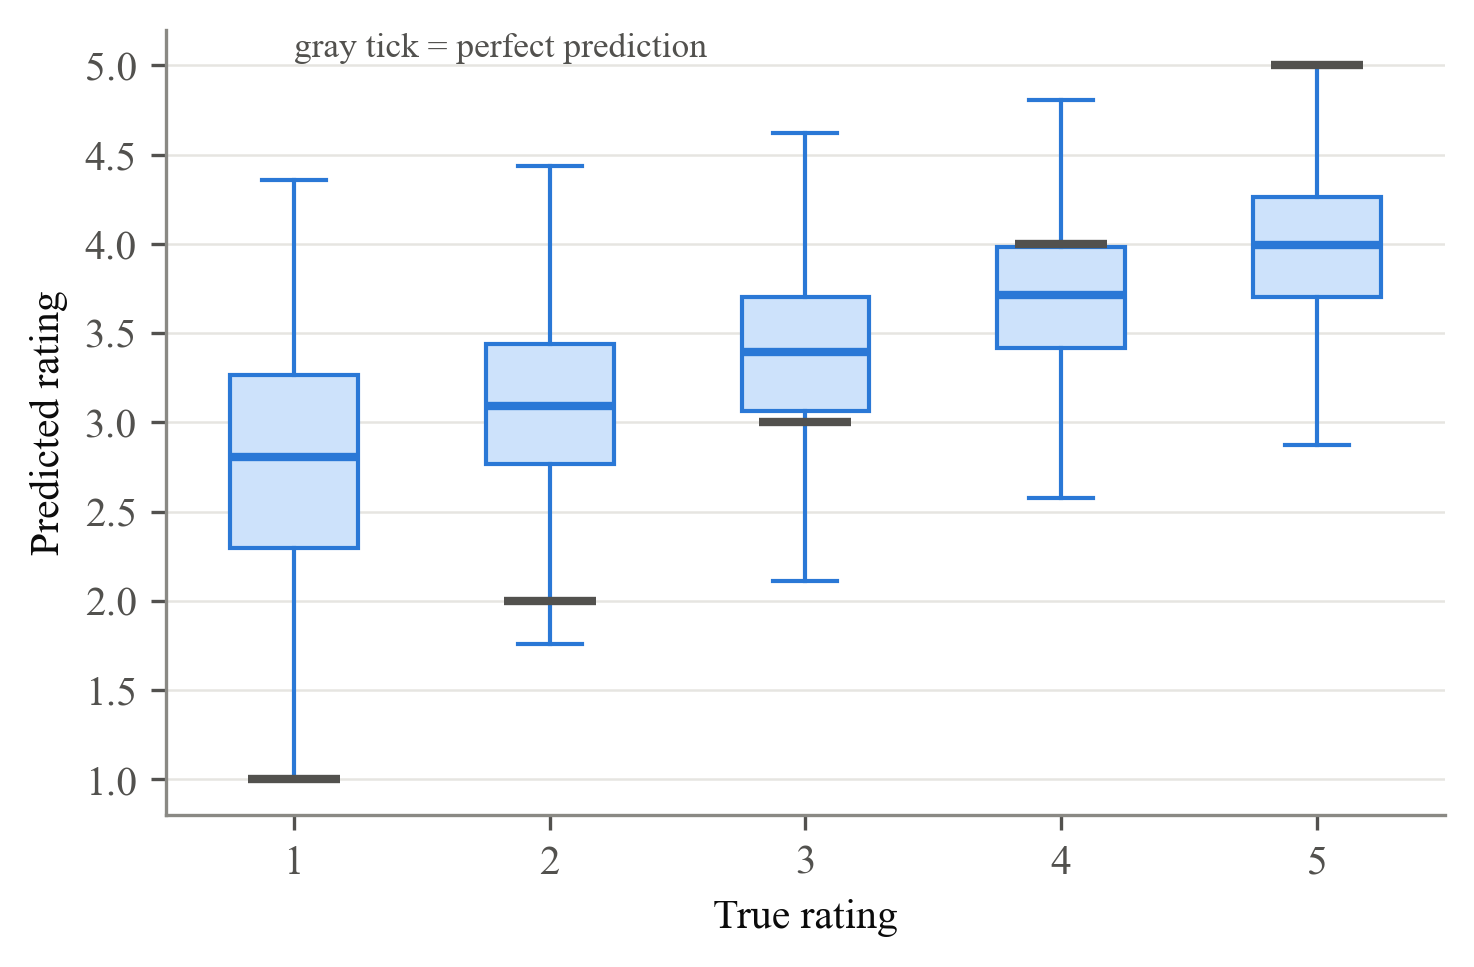

#### Observations

- Low actual ratings tend to be overpredicted, while ratings of 5 tend to be underpredicted.
- Predicted ratings have a standard deviation of 0.58, compared with 1.13 for actual ratings.
- Average predictions are 2.77 for actual ratings of 1 and 3.97 for actual ratings of 5.

Source: `figures/final_predicted_by_true_rating.png`.


In [ ]:
# V10  (a) Share of test ratings at each star value: true ratings vs tuned predictions rounded to
#      the nearest star. A narrower blue profile = predictions compressed toward the middle.
#      (b) Distribution of errors (predicted - true) for both SVDs. Centered near 0 = little
#      overall bias; the legend gives each model's mean error and SD of errors.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
lv = np.arange(1, 6)
true_share = f.actual.round().astype(int).value_counts(normalize=True).reindex(lv, fill_value=0)
pred_share = f.predicted.round().clip(1, 5).astype(int).value_counts(normalize=True).reindex(lv, fill_value=0)
w = 0.38
label_bars(axes[0], axes[0].bar(lv - w / 2, true_share, w, color=ORANGE, label="True ratings"), "{:.0%}")
label_bars(axes[0], axes[0].bar(lv + w / 2, pred_share, w, color=BLUE, label="Tuned predictions (rounded)"), "{:.0%}")
axes[0].set_xticks(lv, lv)
axes[0].set(xlabel="Rating (stars)", ylabel="Share of test ratings", ylim=(0, max(pred_share.max(), true_share.max()) * 1.2),
            title="V10a. Predictions cluster between 3 and 4")
axes[0].legend(loc="upper left", fontsize=8); axes[0].grid(axis="x", visible=False)

rb = np.arange(-4, 4.01, 0.1)
for fr, name, col in ((f_untuned, "Untuned SVD", INK_2), (f_tuned, "Tuned SVD", BLUE)):
    axes[1].hist(fr.err, bins=rb, histtype="step", lw=1.8, color=col, density=True,
                 label=f"{name} (mean {fr.err.mean():+.3f}, SD {fr.err.std():.3f})")
axes[1].axvline(0, color=ORANGE, ls="--", lw=1)
axes[1].set(xlabel="Prediction error (predicted minus true)", ylabel="Density",
            title="V10b. Residual distribution on the test set")
axes[1].legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# V11  Mean signed error (predicted - true) at each true rating, both SVDs. Bars above zero =
#      over-prediction, below = under-prediction. Longer bars at 1 and 5 = compression.
sig = pd.DataFrame({"Untuned SVD": f_untuned.groupby("actual")["err"].mean(),
                    "Tuned SVD": f_tuned.groupby("actual")["err"].mean()})
fig, ax = plt.subplots(figsize=(7, 3.6))
x, w = np.arange(5), 0.38
label_bars(ax, ax.bar(x - w / 2, sig["Untuned SVD"], w, color=INK_2, alpha=0.6, label="Untuned SVD"), "{:+.2f}")
label_bars(ax, ax.bar(x + w / 2, sig["Tuned SVD"], w, color=BLUE, label="Tuned SVD"), "{:+.2f}")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, [int(v) for v in sig.index])
ax.set(xlabel="True rating", ylabel="Mean signed error", title="V11. Over-prediction of low ratings, under-prediction of high")
ax.legend(); ax.grid(axis="x", visible=False)
plt.show()

#### Observations: V9-V11: Prediction Distributions and Errors

- Predictions are concentrated near the middle of the rating scale. Their standard deviation is 0.58, compared with 1.13 for actual ratings.
- Ratings of 1 receive an average prediction of 2.77, an overprediction of 1.77 points.
- Ratings of 5 receive an average prediction of 3.97, an underprediction of approximately 1.03 points.
- The rounded-prediction matrix in V9b shows how each actual rating is distributed across predicted star values. Rounding is used only for visualization; RMSE and MAE use continuous predictions.
- V10 compares the rating distributions and residual distributions. A small overall mean residual can conceal substantial errors within individual rating categories.
- V11 shows the direction of error at each actual rating. Errors are generally larger away from the middle of the scale.
- This pattern is consistent with predictions being pulled toward the mean. These plots do not isolate the separate effects of the loss function, regularization, and limited training information.


### 2.3 Error Heterogeneity by Training Support

Training support is the number of training ratings associated with a user or movie. Test ratings are divided into approximately equal-sized groups according to these counts. These are groups of **test ratings**, not equal-sized groups of distinct users or movies.


In [ ]:
# 2.3  Error by how much training data a user or movie has.
#      Test ratings are split into five equal-sized groups (quintiles) by the user's (or movie's)
#      number of training ratings, and RMSE is computed within each group.
def quintile_rmse(frame, col):
    g = (frame.merge(u_n, left_on=C.USER, right_index=True, how="left")
              .merge(i_n, left_on=C.ITEM, right_index=True, how="left")
              .fillna({"user_train_ratings": 0, "item_train_ratings": 0}))
    q = g.groupby(pd.qcut(g[col], 5, duplicates="drop"), observed=True).agg(
        n=("err", "size"), rmse=("err", rmse), lo=(col, "min"), hi=(col, "max"))
    q.index = [f"{int(a)}-{int(b)}" for a, b in zip(q.lo, q.hi)]
    return q[["n", "rmse"]]

quint = {(col, name): quintile_rmse(fr, col)
         for col in ("user_train_ratings", "item_train_ratings")
         for name, fr in (("Untuned SVD", f_untuned), ("Tuned SVD", f_tuned))}
for col in ("user_train_ratings", "item_train_ratings"):
    print(f"Test RMSE by quintile of {col} (lightest to heaviest):")
    display(pd.concat({name: quint[(col, name)]["rmse"] for name in ("Untuned SVD", "Tuned SVD")}, axis=1)
              .assign(n=quint[(col, "Tuned SVD")]["n"]))

In [ ]:
# V12  (a, b) RMSE per quintile for users and for movies, tuned vs untuned SVD.
#      (c) One dot per user (users with at least 5 test ratings, so their RMSE is not pure noise):
#      training ratings on a log scale vs that user's test RMSE; the orange line is the median
#      RMSE within each tenth of users by activity.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col, ttl in ((axes[0], "user_train_ratings", "V12a. Users"), (axes[1], "item_train_ratings", "V12b. Movies")):
    for name, color in (("Untuned SVD", INK_2), ("Tuned SVD", BLUE)):
        q = quint[(col, name)]
        ax.plot(range(len(q)), q.rmse, marker="o", color=color, label=name, alpha=0.9 if name == "Tuned SVD" else 0.6)
        if name == "Tuned SVD":
            label_points(ax, range(len(q)), q.rmse, fmt="{:.3f}", dy=-13)
    ax.set_xticks(range(len(q)), q.index, fontsize=8)
    ax.set(xlabel="Training ratings (quintile range)", ylabel="Test RMSE", title=ttl + ": RMSE by training volume")
    ax.legend(fontsize=8); ax.grid(axis="x", visible=False)

pu = (f_tuned.groupby(C.USER).agg(rmse=("err", rmse), n_test=("err", "size")).join(u_n))
pu = pu[pu.n_test >= 5]
axes[2].scatter(pu.user_train_ratings, pu.rmse, s=10, alpha=0.35, color=BLUE)
b = pu.groupby(pd.qcut(pu.user_train_ratings, 10), observed=True).agg(x=("user_train_ratings", "median"),
                                                                     y=("rmse", "median"))
axes[2].plot(b.x, b.y, color=ORANGE, marker="o", lw=2, label="median per decile")
axes[2].set_xscale("log")
axes[2].set(xlabel="User's training ratings (log scale)", ylabel="User's test RMSE",
            title="V12c. Per-user RMSE (users with 5+ test ratings)")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Report Figure: Tuned SVD Test RMSE by Users' and Movies' Number of Training Ratings

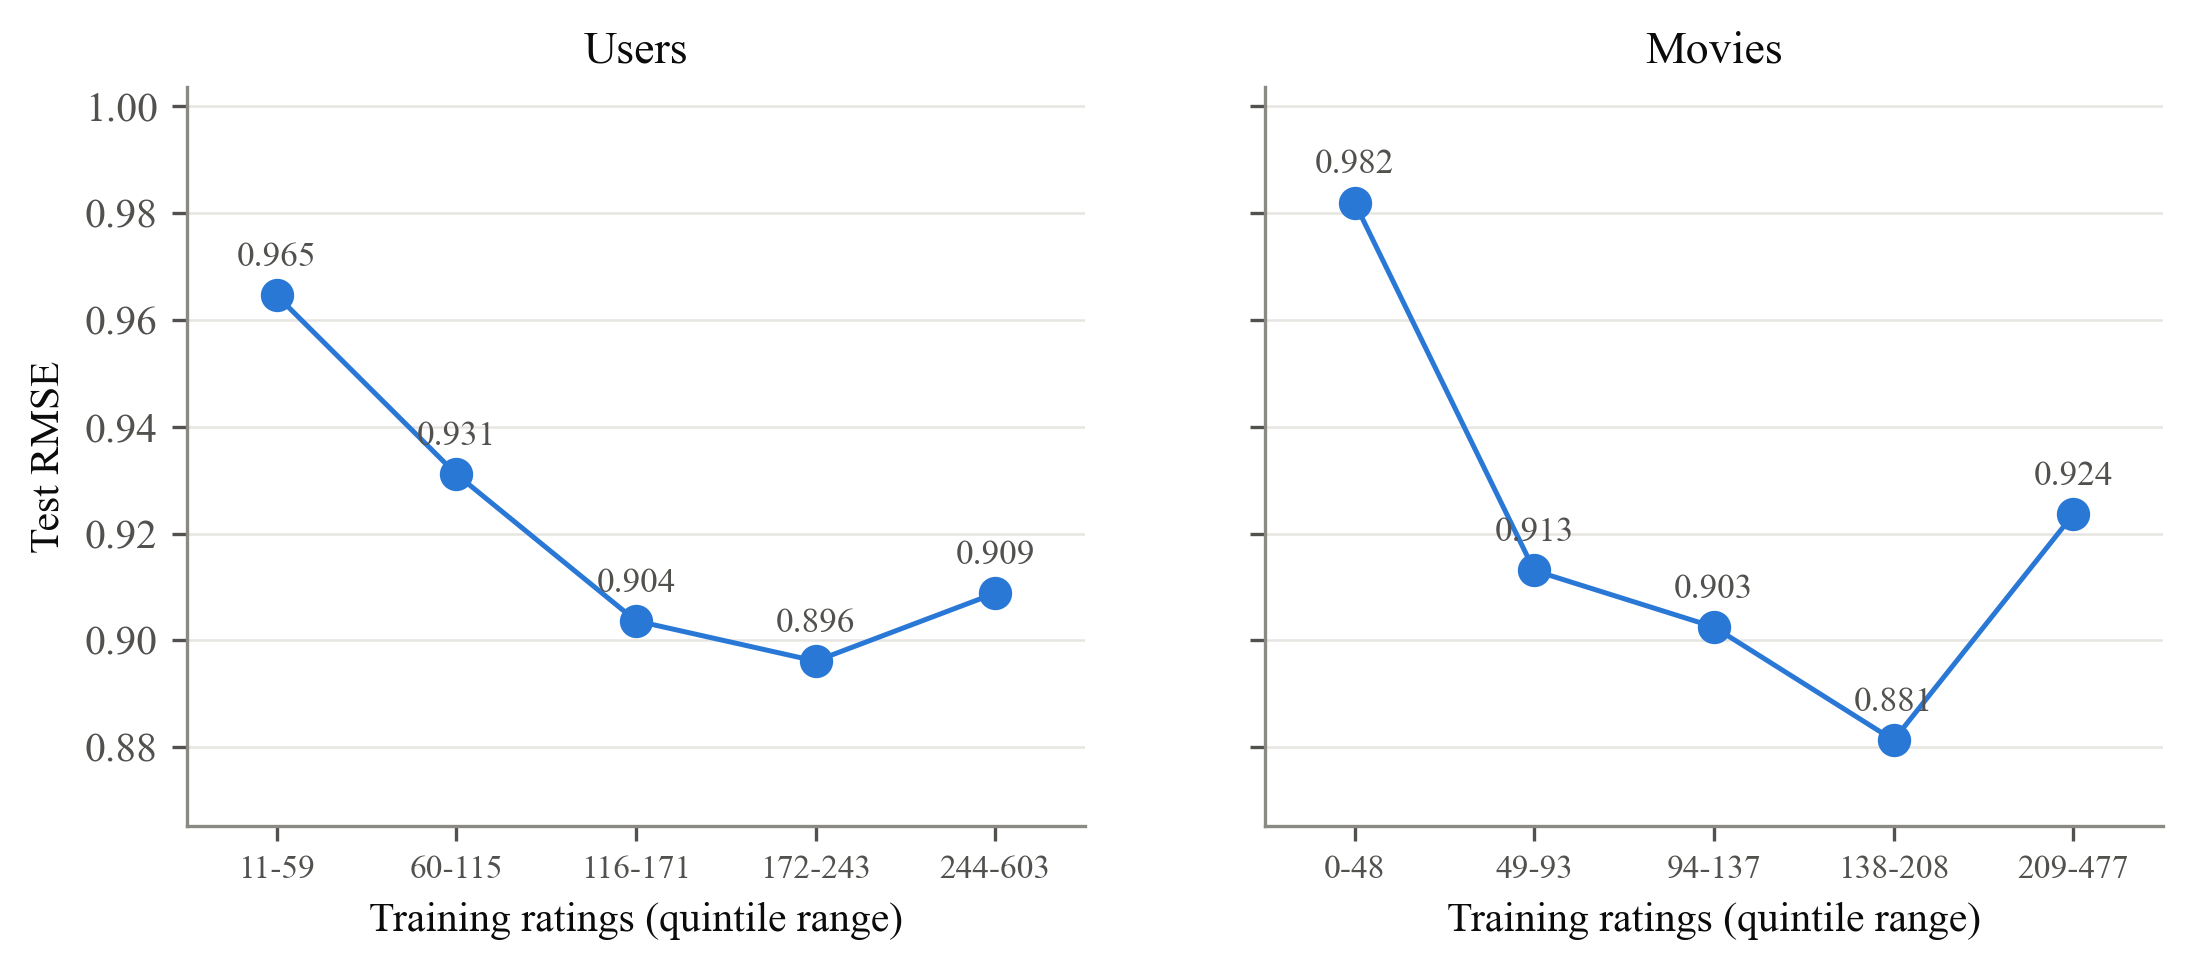

#### Observations

- The lowest user-support group of test ratings has RMSE 0.965.
- The lowest movie-support group of test ratings has RMSE 0.982.
- The groups contain approximately equal numbers of test ratings, ordered by user or movie training count.

Source: `figures/final_rmse_by_support.png`.


#### Observations: V12: Error by Training Support

- The group of test ratings associated with users who have 11-59 training ratings has RMSE 0.965. The other user-support groups range from 0.896 to 0.931.
- The group associated with movies that have 0-48 training ratings has RMSE 0.982. The other movie-support groups range from 0.881 to 0.924.
- The lowest-support groups have the highest errors, but error does not decrease steadily across every successive group.
- V12a and V12b compare the tuned and default models within the same support groups.
- V12c shows variation in individual users' RMSE at each activity level. Only users with at least five test ratings are included; their individual estimates can still be noisy.


### 2.4 Case Analysis of the Largest Prediction Errors

The next table and chart examine the 12 test ratings with the largest absolute prediction errors. User and movie training counts provide context for these cases.


In [ ]:
# 2.4  The 12 individual test ratings with the largest absolute error, with how much training
#      data the user and the movie had, to see whether big misses come from thin evidence or from
#      a user disagreeing with an otherwise well-established movie.
worst = (f_tuned.assign(abs_err=f_tuned.err.abs()).nlargest(12, "abs_err")
          .assign(title=lambda d: d[C.ITEM].map(titles))
          .merge(i_n, left_on=C.ITEM, right_index=True, how="left")
          .merge(u_n, left_on=C.USER, right_index=True, how="left")
          .reset_index(drop=True))
display(worst[[C.USER, "title", "actual", "predicted", "abs_err", "item_train_ratings", "user_train_ratings"]])

# V13  Dumbbell chart: orange = what the user actually gave, blue = what the tuned SVD predicted.
#      The length of the grey line is the size of the miss.
fig, ax = plt.subplots(figsize=(8, 4.6))
y = np.arange(len(worst))
ax.hlines(y, worst.actual, worst.predicted, color=INK_2, lw=1.5)
ax.scatter(worst.actual, y, color=ORANGE, s=50, zorder=3, label="True rating")
ax.scatter(worst.predicted, y, color=BLUE, s=50, zorder=3, label="Tuned SVD prediction")
ax.set_yticks(y, [f"{t[:34]} (user {u})" for t, u in zip(worst.title, worst[C.USER])], fontsize=8)
ax.invert_yaxis(); ax.set_xlim(0.7, 5.3)
ax.set(xlabel="Rating", title="V13. The 12 largest test errors")
ax.legend(loc="lower right", fontsize=8); ax.grid(axis="y", visible=False)
plt.show()

#### Observations: V13: Largest Individual Errors

- The largest errors include ratings for *Another Stakeout*, *Jerry Maguire*, *Amadeus*, *The World of Apu*, and *The English Patient* in the saved results.
- Each connecting line shows the difference between an actual rating and the model's prediction. A longer line indicates a larger error.
- Training counts help distinguish cases with limited supporting data from errors involving well-established users or movies.
- These selected cases illustrate model failures; they do not establish how common each failure type is or prove its cause.

### 2.5 Model Improvement Priorities and Validation Strategy

- **Limited training support:** Evaluate stronger shrinkage for sparse profiles or additional information, such as movie genres. A larger movie-bias penalty (`reg_bi`) is one option to test.
- **Errors at extreme ratings:** Report performance by actual rating and consider validation criteria that reflect the intended recommendation task.
- **Ranking quality:** Include ranking metrics in future model selection when the intended output is a recommendation list.
- **Search boundaries:** Test values beyond the remaining boundaries or consider random search, as discussed by Bergstra and Bengio (2012).
- **Evaluation discipline:** Assess proposed changes using training-based validation. The current held-out test results should not be used to choose new settings.


### 2.6 Ranking Evaluation: Candidate Set, Precision, and Recall

The candidate set contains only the movies each user rated in the test partition.

- A movie is **recommended** if it is among that user's ten highest predicted ratings and its predicted rating is at least 4.
- A movie is **relevant** if its actual rating is at least 4.
- **Precision@10** is the proportion of qualifying recommendations that are relevant. Its denominator can be less than ten because of the predicted-rating cutoff.
- **Recall@10** is the proportion of relevant test items that appear among the qualifying recommendations.
- Users with no qualifying recommendations receive zero precision. Users with no relevant test items receive zero recall.
- The reported values are averages of the per-user metrics over 942 users.

The implementation follows the threshold-based definition used in Surprise's FAQ.


In [ ]:
# 2.6  Ranking metrics on the held-out candidate set.
#      precision_recall_at_k (src/evaluation.py) works per user on that user's TEST ratings only:
#        recommended = in the user's top k by prediction AND predicted rating >= 4
#        relevant    = true rating >= 4
#        precision@k = |recommended & relevant| / |recommended|   (0 if nothing recommended)
#        recall@k    = |recommended & relevant| / |relevant|      (0 if nothing relevant)
#      then averages over the 942 users scored. Same frames as 2.1, so same predictions.
FRAMES = {"Bias-only baseline": f_base, "Untuned SVD": f_untuned, "Tuned SVD": f_tuned}
rank_rows, per_user = {}, {}
for name, frame in FRAMES.items():
    s, pu_ = precision_recall_at_k(frame)
    rank_rows[name] = {"precision@10": s["precision_at_k"], "recall@10": s["recall_at_k"], "users": s["users_scored"]}
    per_user[name] = pu_
rank = pd.DataFrame(rank_rows).T
display(rank)

ref = saved("final_evaluation.json")["ranking"]
check("baseline precision@10", rank.loc["Bias-only baseline", "precision@10"], ref["baseline_only"]["precision_at_k"])
check("untuned precision@10", rank.loc["Untuned SVD", "precision@10"], ref["svd"]["precision_at_k"])
check("tuned precision@10", rank.loc["Tuned SVD", "precision@10"], ref["svd_tuned"]["precision_at_k"])
check("untuned recall@10", rank.loc["Untuned SVD", "recall@10"], ref["svd"]["recall_at_k"])
check("tuned recall@10", rank.loc["Tuned SVD", "recall@10"], ref["svd_tuned"]["recall_at_k"])

# Precision and recall at several list lengths, to see whether the drop is specific to k = 10.
KS = [1, 3, 5, 10, 15, 20]
curves = {}
for name, fr in FRAMES.items():
    pts = []
    for list_len in KS:
        s, _ = precision_recall_at_k(fr, k=list_len)
        pts.append({"precision_at_k": s["precision_at_k"], "recall_at_k": s["recall_at_k"]})
    curves[name] = pd.DataFrame(pts, index=KS)
display(pd.concat({n: c["precision_at_k"] for n, c in curves.items()}, axis=1).rename_axis("k")
          .add_prefix("precision@k: "))

In [ ]:
# V14  (a) Precision@10 and recall@10 per model. (b, c) The same metrics for list lengths 1 to 20;
#      the dotted line marks k = 10, the value reported. A gap that persists across k is not an
#      artifact of choosing k = 10.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
x, w = np.arange(3), 0.38
label_bars(axes[0], axes[0].bar(x - w / 2, rank["precision@10"], w, color=BLUE, label="Precision@10"))
label_bars(axes[0], axes[0].bar(x + w / 2, rank["recall@10"], w, color=AQUA, label="Recall@10"))
axes[0].set_xticks(x, ["Bias-only\nbaseline", "Untuned\nSVD", "Tuned\nSVD"])
axes[0].set(ylim=(0, 0.75), title="V14a. Ranking quality at k = 10 (higher is better)")
axes[0].legend(ncol=2, fontsize=8); axes[0].grid(axis="x", visible=False)

colors = {"Bias-only baseline": AQUA, "Untuned SVD": INK_2, "Tuned SVD": BLUE}
for ax, metric, ttl in ((axes[1], "precision_at_k", "V14b. Precision@k"), (axes[2], "recall_at_k", "V14c. Recall@k")):
    for name, cv in curves.items():
        ax.plot(cv.index, cv[metric], marker="o", color=colors[name], label=name)
    ax.axvline(10, ls=":", color=INK_2, lw=1)
    ax.set(xlabel="List length k", title=ttl); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# V15  (a) Histogram of per-user precision@10 for both SVDs.
#      (b) For each user, tuned minus untuned precision@10: the share of users who got worse,
#      stayed the same, or got better. The average in V14 can hide how the change is spread.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
pb = np.linspace(0, 1, 11)
for name, col in (("Untuned SVD", INK_2), ("Tuned SVD", BLUE)):
    axes[0].hist(per_user[name]["precision_at_k"], bins=pb, histtype="step", lw=2, color=col,
                 label=f"{name} (mean {per_user[name]['precision_at_k'].mean():.3f})")
axes[0].set(xlabel="Per-user precision@10", ylabel="Users", title="V15a. Distribution of per-user precision@10")
axes[0].legend(fontsize=8)

d = (per_user["Tuned SVD"].set_index(C.USER)["precision_at_k"]
     - per_user["Untuned SVD"].set_index(C.USER)["precision_at_k"])
share = pd.Series({"Worse after tuning": (d < 0).mean(), "Unchanged": (d == 0).mean(), "Better after tuning": (d > 0).mean()})
label_bars(axes[1], axes[1].bar(share.index, share, color=[ORANGE, INK_2, BLUE]), fmt="{:.1%}")
axes[1].set(ylabel="Share of users", ylim=(0, max(share) * 1.2), title="V15b. Per-user change in precision@10 from tuning")
axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

#### Observations: V14 and V15: Ranking Performance

- Precision@10 decreases from 0.619 for the default SVD to 0.596 for the tuned SVD.
- Recall@10 decreases from 0.282 to 0.261. Lower rating error therefore does not correspond to better performance on these ranking metrics.
- Selection minimizes CV RMSE rather than precision or recall. Compressed predictions can leave relevant items below the cutoff of 4 and reduce recall.
- Precision depends on which items exceed that cutoff. The zero-precision convention for users with no qualifying recommendations also affects the average.
- These mechanisms are possible contributors to the decline; their individual effects were not isolated experimentally.
- V14b and V14c compare performance across list lengths, while V15 shows how changes in precision are distributed across users.
- The distinction between rating accuracy and top-N performance is also discussed by Cremonesi et al. (2010).

**Candidate-set limitation**

- Every candidate in this evaluation is an item the user chose to rate. The results do not measure ranking quality over all available movies.
- The next analysis considers movies present in training that the user has not rated in training. Those lists may include held-out rated movies, exclude movies absent from training, and do not apply the predicted-rating cutoff of 4.


### 2.7 Catalog Exposure and Recommendation Reliability

For each training user, the model ranks all movies present in training except those that the user rated in training. The ten highest-scoring candidates form the recommendation list. The analysis examines the amount of evidence supporting these recommendations and how widely particular movies are recommended.


In [ ]:
# 2.7  Full-catalog top-10 lists: for every user, score EVERY movie the user has not rated in
#      training and keep the 10 highest. score_matrix computes predictions for all training-known users and movies at once
#      (mu + b_u + b_i + p_u.q_i, clipped to 1-5) and checks them against SVD.predict on a sample.
#      For each model we measure: share of top-10 slots going to thin-evidence movies, distinct
#      movies recommended, catalog coverage, and the single most widely recommended movie.
THIN = C.THIN_EVIDENCE   # fewer than 10 training ratings = thin-evidence movie
lists, rows = {}, {}
for name, algo in (("Untuned SVD", untuned), ("Tuned SVD", tuned)):
    scores, _ = score_matrix(algo)                       # verified against SVD.predict inside
    top = top_n_from_scores(algo.trainset, scores, n=C.TOP_K)
    top["item_train_ratings"] = top[C.ITEM].map(i_n).fillna(0)
    lists[name] = top
    reach = top.groupby(C.ITEM)[C.USER].nunique() / top[C.USER].nunique()
    rows[name] = {"recs to thin-evidence movies": (top.item_train_ratings < THIN).mean(),
                  "distinct movies recommended": top[C.ITEM].nunique(),
                  "catalog coverage": top[C.ITEM].nunique() / len(items),
                  "most-recommended movie": titles[reach.idxmax()],
                  "its share of users' lists": reach.max()}
exposure = pd.DataFrame(rows).T
display(exposure)

In [ ]:
# V16  (a) Cumulative share of all recommendations (y) backed by at most x training ratings; a
#      curve that rises early = many recommendations rest on very few ratings. Dashed = 10.
#      (b) Share of top-10 slots filled by thin-evidence movies. (c) The tuned SVD's 12 most
#      widely recommended movies, with the share of users who see each and its training count n.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1, 1, 1.5]})

for name, col in (("Untuned SVD", INK_2), ("Tuned SVD", BLUE)):
    v = np.sort(lists[name]["item_train_ratings"].to_numpy())
    axes[0].step(np.maximum(v, 0.8), np.arange(1, len(v) + 1) / len(v), where="post", color=col, lw=2, label=name)
axes[0].axvline(THIN, ls="--", color=ORANGE, lw=1)
axes[0].annotate("10 ratings", (THIN, 0.03), xytext=(4, 0), textcoords="offset points", fontsize=8, color=ORANGE)
axes[0].set_xscale("log")
axes[0].set(xlabel="Training ratings of recommended movie (log)", ylabel="Cumulative share of recommendations",
            title="V16a. Evidence behind each recommendation")
axes[0].legend(fontsize=8)

label_bars(axes[1], axes[1].bar(exposure.index, exposure["recs to thin-evidence movies"].astype(float),
                                color=[INK_2, BLUE]), fmt="{:.1%}")
axes[1].set(ylabel="Share of all top-10 slots", ylim=(0, 0.75),
            title="V16b. Recommendations to thin-evidence movies")
axes[1].grid(axis="x", visible=False)

top_t = lists["Tuned SVD"]
reach = (top_t.groupby(C.ITEM)[C.USER].nunique() / top_t[C.USER].nunique()).nlargest(12)
n_tr = reach.index.map(i_n).fillna(0).astype(int)
bars = axes[2].barh([titles[i][:38] for i in reach.index], reach, color=[ORANGE if n < THIN else BLUE for n in n_tr])
for b_, n in zip(bars, n_tr):
    axes[2].annotate(f"{b_.get_width():.0%}  (n = {n})", (b_.get_width(), b_.get_y() + b_.get_height() / 2),
                     xytext=(3, 0), textcoords="offset points", va="center", fontsize=8, color=INK_2)
axes[2].invert_yaxis(); axes[2].set_xlim(0, 1.2)
axes[2].set(xlabel="Share of users whose top 10 includes it",
            title="V16c. Tuned SVD's most-recommended movies (orange = fewer than 10 training ratings)")
axes[2].tick_params(axis="y", labelsize=8); axes[2].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

#### Observations: V16: Evidence Supporting Catalog Recommendations

- In the saved run, 56.5% of the tuned model's recommendation slots go to movies with fewer than ten training ratings, compared with approximately 0.1% for the default SVD.
- *Pather Panchali*, with seven training ratings, appears in approximately 97% of users' lists. *The Saint of Fort Washington*, with two training ratings, appears in approximately 87%.
- V16a shows the cumulative share of recommendations by movie training count. V16b summarizes recommendations to sparsely rated movies, and V16c shows the most widely recommended titles.
- These exposure statistics describe catalog-wide lists. They are separate from precision and recall calculated using held-out rated items.
- Broad exposure based on very few ratings raises questions about reliability and recommendation diversity, which can inform the report's Ethical Considerations section.
- The percentages above describe the saved run. This notebook recomputes the lists; small differences can occur across numerical-library builds when candidate scores are nearly tied.


### 2.8 Temporal Evaluation and Cold-Start Limitations

A random split can place ratings in training that occur after the ratings being predicted. Two chronological alternatives examine the sensitivity of the results to the evaluation protocol:

- **Per-user chronological split:** Each user's latest 20% of ratings are held out. Later ratings from other users may still be included in training.
- **Global chronological split:** Ratings are divided at a common chronological boundary. This removes later-dated training information but leaves many test users without training histories.
- **Fixed configuration:** The selected hyperparameters are reused for these comparisons; the model is not retuned for each split.

Differences between these splits reflect changes in available information and test-set composition. They do not isolate the effect of temporal leakage.


In [ ]:
# 2.8  Refit the bias-only baseline and the tuned SVD (same hyperparameters, no re-tuning) on each
#      of the three frozen splits, and record per split:
#        future info share  share of test ratings whose movie has a training rating dated LATER
#                           than the test rating (what the model "knows about the future")
#        new-user share     share of test ratings from users with no training ratings (cold start)
#        RMSE overall, and for returning vs new users.
rows = []
for strategy in C.SPLIT_STRATEGIES:
    a = make_split(ratings, strategy)                     # committed assignment, read from results/
    tr, te = train_test(ratings, a)
    info = describe_split(ratings, a, strategy)
    ts_tr, ts_te = to_trainset(tr), to_testset(te)
    row = {"split": strategy,
           "future info share": info["test_ratings_with_future_train_ratings_of_same_item"]}
    for name, algo in (("Bias-only baseline", make_baseline()), ("Tuned SVD", make_svd(TUNED))):
        algo.fit(ts_tr)
        fr = predictions_frame(algo.test(ts_te))
        err = fr.predicted - fr.actual
        cold = ~fr[C.USER].isin(set(tr[C.USER]))
        row[f"{name} RMSE"] = rmse(err)
        if name == "Tuned SVD":
            row["new-user share"] = cold.mean()
            row["Tuned RMSE returning users"] = rmse(err[~cold])
            row["Tuned RMSE new users"] = rmse(err[cold]) if cold.any() else np.nan
    rows.append(row)
temporal = pd.DataFrame(rows).set_index("split")
display(temporal)

ts = saved("temporal_summary.json")
for s in C.SPLIT_STRATEGIES:
    check(f"{s} tuned RMSE", temporal.loc[s, "Tuned SVD RMSE"], ts["svd_tuned_rmse_by_split"][s])
    check(f"{s} future-information share", temporal.loc[s, "future info share"], ts["future_information_by_split"][s])
check("global chrono new-user share", temporal.loc["global_chrono", "new-user share"],
      ts["global_chrono_cold_user_share_of_test"])

In [ ]:
# V17  (a) Test RMSE of both models on each split. (b) What each split leaks (future information)
#      or withholds (users never seen in training). (c) On the global split, RMSE for returning
#      vs new users, which shows the global split's error is mostly a cold-start effect.
names = {"random": "Random", "user_chrono": "Per-user\nchronological", "global_chrono": "Global\nchronological"}
xl = [names[s] for s in temporal.index]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

for col, color, dy in (("Bias-only baseline RMSE", ORANGE, 8), ("Tuned SVD RMSE", BLUE, -14)):
    axes[0].plot(range(3), temporal[col], marker="o", color=color, label=col.replace(" RMSE", ""))
    label_points(axes[0], range(3), temporal[col], fmt="{:.3f}", dy=dy)
axes[0].set_xticks(range(3), xl); axes[0].set_xlim(-0.4, 2.4)
axes[0].set(ylabel="Test RMSE", title="V17a. Test RMSE by split"); axes[0].legend(fontsize=8)
axes[0].grid(axis="x", visible=False)

x, w = np.arange(3), 0.38
label_bars(axes[1], axes[1].bar(x - w / 2, temporal["future info share"], w, color=ORANGE,
                                label="test ratings whose movie has later training ratings"), fmt="{:.1%}")
label_bars(axes[1], axes[1].bar(x + w / 2, temporal["new-user share"], w, color=INK_2,
                                label="test ratings from users unseen in training"), fmt="{:.1%}")
axes[1].set_xticks(x, xl); axes[1].set(ylim=(0, 1.2), ylabel="Share of test ratings",
                                       title="V17b. What each split leaks or withholds")
axes[1].legend(fontsize=7.5, loc="upper center"); axes[1].grid(axis="x", visible=False)

g = temporal.loc["global_chrono"]
label_bars(axes[2], axes[2].bar(["Returning users", "New users"],
                                [g["Tuned RMSE returning users"], g["Tuned RMSE new users"]],
                                color=[BLUE, INK_2]))
axes[2].set(ylim=(0, 1.2), ylabel="Test RMSE", title="V17c. Global split: returning vs new users")
axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

#### Report Figure: Test RMSE of the Tuned SVD and the Bias-Only Baseline Under Three Train/Test Splits

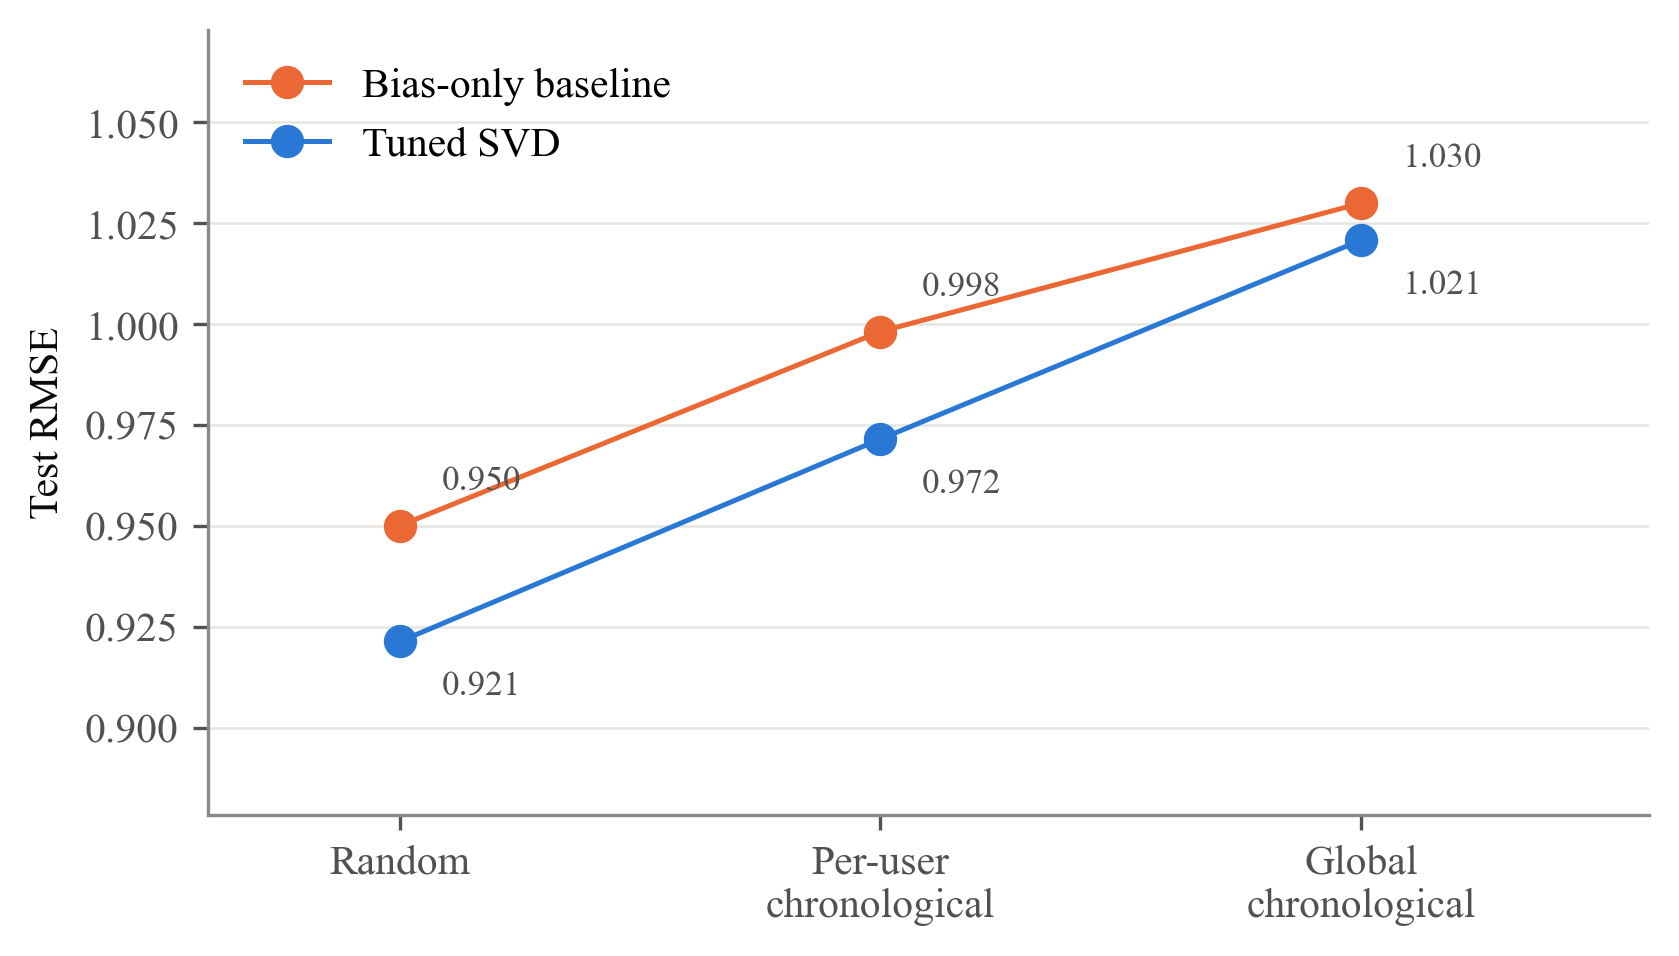

#### Observations

- Tuned SVD RMSE is 0.921, 0.972, and 1.021 for the random, per-user chronological, and global chronological splits, respectively.
- The RMSE advantage over the bias-only baseline decreases from approximately 0.029 to 0.027 to 0.009.
- The split comparisons reflect both temporal-information differences and changes in the test population.

Source: `figures/temporal_rmse_by_split.png`.


#### Observations: V17: Chronological Evaluation

- Tuned SVD RMSE is 0.921 on the random split, 0.972 on the per-user chronological split, and 1.021 on the global chronological split.
- The global-split RMSE is 10.8% higher than the random-split RMSE.
- On the random split, 98.0% of test ratings concern movies with later-dated ratings in training.
- The per-user split retains this form of future information for 94.4% of test ratings because other users' later ratings can remain in training.
- On the global split, 85.2% of test ratings come from users absent from training. RMSE is 1.028 for these users and 0.979 for returning users.
- The tuned model's RMSE advantage over the bias-only baseline narrows from approximately 0.029 on the random split to 0.009 on the global split.
- The global result is strongly influenced by cold-start users. The difference from the random split should not be interpreted as a pure estimate of leakage.
- Together, these results suggest that the random-split score may be optimistic for deployment. Evaluation-protocol limitations are discussed by Campos et al. (2014).


In [ ]:
# 2.9  The report's evaluation tables, rebuilt from the recomputed results, plus checks against every
#      committed final_*.csv this section cites and the committed report figure.
from IPython.display import Image

# (a) Report Table X: test-set rating error and ranking quality by model.
report_models = pd.DataFrame({"RMSE": table["Test RMSE"], "MAE": table["Test MAE"],
                              "Precision@10": rank["precision@10"], "Recall@10": rank["recall@10"]}).loc[MODELS]
print("Report Table X. Test-Set Rating Error and Ranking Quality by Model")
display(report_models.round(3))

# (b) Report Table X: tuned SVD test RMSE under three train/test splits.
report_splits = temporal[["Tuned SVD RMSE", "future info share", "new-user share"]].rename(columns={
    "Tuned SVD RMSE": "Test RMSE",
    "future info share": "Test ratings with later training ratings of the same movie",
    "new-user share": "Test ratings from users unseen in training"})
print("Report Table X. Tuned SVD Test RMSE Under Three Train/Test Splits")
display(report_splits.round(3))

# (c) Checks against the committed CSV files.
mc = pd.read_csv(RES / "final_model_comparison.csv").set_index("model")
for key, name in (("baseline_only", "Bias-only baseline"), ("svd", "Untuned SVD"), ("svd_tuned", "Tuned SVD")):
    check(f"final_model_comparison.csv {key} RMSE", report_models.loc[name, "RMSE"], mc.loc[key, "rmse"])
    check(f"final_model_comparison.csv {key} MAE", report_models.loc[name, "MAE"], mc.loc[key, "mae"])

rm = pd.read_csv(RES / "final_ranking_metrics.csv").set_index("model")
for key, name in (("baseline_only", "Bias-only baseline"), ("svd", "Untuned SVD"), ("svd_tuned", "Tuned SVD")):
    check(f"final_ranking_metrics.csv {key} precision@10", report_models.loc[name, "Precision@10"], rm.loc[key, "precision_at_k"])
    check(f"final_ranking_metrics.csv {key} recall@10", report_models.loc[name, "Recall@10"], rm.loc[key, "recall_at_k"])

etr = pd.read_csv(RES / "final_error_by_true_rating.csv").set_index("actual")
for r in (1.0, 5.0):
    check(f"final_error_by_true_rating.csv mean pred | true {int(r)}", by_rating.loc[r, "mean predicted (tuned)"],
          etr.loc[r, "mean_predicted"])

for col, fname in (("user_train_ratings", "final_rmse_by_user_train_ratings.csv"),
                   ("item_train_ratings", "final_rmse_by_item_train_ratings.csv")):
    committed = pd.read_csv(RES / fname)["rmse"].to_numpy()
    mine = quint[(col, "Tuned SVD")]["rmse"].to_numpy()
    check(f"{fname} lightest quintile", mine[0], committed[0])
    check(f"{fname} max |quintile difference|", float(np.abs(mine - committed).max()), 0.0)

tc = pd.read_csv(RES / "temporal_comparison.csv")
tg = tc[(tc.strategy == "global_chrono") & (tc.model == "svd_tuned")].iloc[0]
check("temporal_comparison.csv global returning-user RMSE", temporal.loc["global_chrono", "Tuned RMSE returning users"], tg.rmse_warm_users)
check("temporal_comparison.csv global new-user RMSE", temporal.loc["global_chrono", "Tuned RMSE new users"], tg.rmse_cold_users)

# (d) The committed report figure for this section, exactly as it appears in the paper.
print("\nReport Figure X (figures/final_predicted_by_true_rating.png):")
display(Image(filename=str(C.FIGURES_DIR / "final_predicted_by_true_rating.png"), width=600))

## 3. Findings, Limitations, and Reproducibility

- **Rating accuracy improves:** Tuning lowers test RMSE from 0.941 to 0.921 and MAE from 0.741 to 0.729.
- **Regularization has the largest sensitivity:** It produces the largest range of mean CV RMSE in both the expanded and refined grids.
- **The search remains bounded:** The selected model reaches three grid boundaries and is the best configuration tested.
- **Predictions are compressed:** Low actual ratings are generally overpredicted, and high actual ratings are generally underpredicted.
- **Limited training support is associated with larger errors:** The lowest user- and movie-support groups of test ratings have RMSE 0.965 and 0.982, respectively.
- **Ranking metrics decline:** Precision@10 decreases from 0.619 to 0.596, and recall@10 decreases from 0.282 to 0.261.
- **Catalog exposure requires separate analysis:** In the saved run, 56.5% of the tuned model's recommendation slots go to movies with fewer than ten training ratings.
- **Evaluation depends on the split:** Chronological splits produce higher RMSE; the global split also contains many users absent from training.
- **Uncertainty remains:** Fold standard deviations are not significance tests for test-set differences, and the observed comparisons do not isolate causal mechanisms.

### References

Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research, 13*, 281–305.

Campos, P. G., Díez, F., & Cantador, I. (2014). Time-aware recommender systems: A comprehensive survey and analysis of existing evaluation protocols. *User Modeling and User-Adapted Interaction, 24*(1–2), 67–119. https://doi.org/10.1007/s11257-012-9136-x

Cremonesi, P., Koren, Y., & Turrin, R. (2010). Performance of recommender algorithms on top-N recommendation tasks. In *Proceedings of the Fourth ACM Conference on Recommender Systems* (pp. 39–46). ACM. https://doi.org/10.1145/1864708.1864721

Hug, N. (2020). Surprise: A Python library for recommender systems. *Journal of Open Source Software, 5*(52), 2174. https://doi.org/10.21105/joss.02174


### 3.1 Numerical Verification and Interpretation Limits

The following table checks 64 numerical claims used in the report against the values available in this notebook, using the report's rounding conventions.

- **OK:** The value matches the report at the stated precision.
- **DIFF:** The value differs and should be investigated before submission.
- Most checks use recomputed evaluation results or the search surfaces selected by `RUN_FULL_SEARCH`. The default-model CV standard deviation is read from the saved evaluation summary.
- A mismatch may reflect differences in inputs, software versions, or execution. It should not automatically be dismissed as a software-version issue.
- Matching values confirm numerical consistency; they do not establish statistical significance or validate every interpretation in the report.

### Evidence and Interpretation

- Reported measurements are drawn from the project result files or explicitly identified notebook recomputations. No synthetic observations are substituted for MovieLens ratings.
- The local MovieLens files passed the project's dataset-count and SHA-256 checks. Tuned test RMSE and MAE were independently recalculated from the 20,000 saved test predictions and matched the evaluation summary.
- Candidate counts and best CV scores were checked against the saved search surfaces. Ranking metrics and chronological RMSE were cross-checked between the saved CSV and JSON files. These consistency checks do not constitute a fresh execution of every search.
- Suggested mechanisms and potential improvements are hypotheses, not established causal findings. Fold standard deviations are not significance tests, and neither the best tested configuration nor the random-split score establishes optimal deployment performance.



In [ ]:
fe_imp = saved("final_evaluation.json")["improvement_over_default"]
sens_others_r = max(v for k, v in sens_r.items() if k != "reg_all")
g_row = temporal.loc["global_chrono"]
claims = [
    # (report statement, recomputed value, value as printed in the report, decimals)
    ("Untuned defaults CV RMSE on the tuning folds", default_cv, 0.9534, 4),
    ("Assignment grid best CV RMSE", best_a.cv_rmse, 0.9502, 4),
    ("Assignment grid gain over defaults", default_cv - best_a.cv_rmse, 0.0032, 4),
    ("Expanded grid best CV RMSE", best_e.cv_rmse, 0.9306, 4),
    ("Refined grid best CV RMSE (selected)", best_r.cv_rmse, 0.9294, 4),
    ("Refined best fold SD", best_r.cv_rmse_sd, 0.0003, 4),
    ("Expanded sensitivity: reg_all", sens_e["reg_all"], 0.0235, 4),
    ("Expanded sensitivity: lr_all", sens_e["lr_all"], 0.0059, 4),
    ("Expanded mean CV RMSE at reg_all 0.02", reg_means.loc[0.02], 0.968, 3),
    ("Expanded mean CV RMSE at reg_all 0.1", reg_means.loc[0.1], 0.944, 3),
    ("Refined sensitivity: reg_all", sens_r["reg_all"], 0.0079, 4),
    ("Refined sensitivity: largest other parameter", sens_others_r, 0.0011, 4),
    ("Refined: reg_all 0.15 best in N of 27", float((best_reg == 0.15).sum()), 24, 0),
    ("Refined: spread of top 10 candidates", surf_ref.cv_rmse.iloc[9] - surf_ref.cv_rmse.iloc[0], 0.0008, 4),
    ("Refined: best of top 3", top3.cv_rmse.min(), 0.9294, 4),
    ("Refined: worst of top 3", top3.cv_rmse.max(), 0.9297, 4),
    ("Tuned SVD test RMSE", rmse_t, 0.921, 3),
    ("Tuned SVD test MAE", mae_t, 0.729, 3),
    ("Untuned SVD test RMSE", rmse_u, 0.941, 3),
    ("Untuned SVD test MAE", mae_u, 0.741, 3),
    ("Bias-only baseline test RMSE", rmse_b, 0.950, 3),
    ("Bias-only baseline test MAE", mae_b, 0.752, 3),
    ("RMSE reduction from tuning", rmse_u - rmse_t, 0.0198, 4),
    ("RMSE reduction from tuning, percent", 100 * (rmse_u - rmse_t) / rmse_u, 2.11, 2),
    ("MAE reduction from tuning", mae_u - mae_t, 0.0123, 4),
    ("Tuned SVD gain over bias-only baseline", rmse_b - rmse_t, 0.029, 3),
    ("Untuned SVD 5-fold CV SD (scale reference only)", fe_imp["default_svd_cv_rmse_sd"], 0.0041, 4),
    ("Tuned SVD training RMSE", tr_t, 0.791, 3),
    ("Train-to-test gap", rmse_t - tr_t, 0.131, 3),
    ("SD of tuned predictions", f_tuned.predicted.std(), 0.58, 2),
    ("SD of true test ratings", f_tuned.actual.std(), 1.13, 2),
    ("Mean prediction when true rating is 1", by_rating.loc[1.0, "mean predicted (tuned)"], 2.77, 2),
    ("Mean prediction when true rating is 5", by_rating.loc[5.0, "mean predicted (tuned)"], 3.97, 2),
    ("RMSE, lowest user-support group of test ratings", quint[("user_train_ratings", "Tuned SVD")]["rmse"].iloc[0], 0.965, 3),
    ("RMSE, other user quintiles (min)", quint[("user_train_ratings", "Tuned SVD")]["rmse"].iloc[1:].min(), 0.896, 3),
    ("RMSE, other user quintiles (max)", quint[("user_train_ratings", "Tuned SVD")]["rmse"].iloc[1:].max(), 0.931, 3),
    ("RMSE, lowest movie-support group of test ratings", quint[("item_train_ratings", "Tuned SVD")]["rmse"].iloc[0], 0.982, 3),
    ("RMSE, other movie quintiles (min)", quint[("item_train_ratings", "Tuned SVD")]["rmse"].iloc[1:].min(), 0.881, 3),
    ("RMSE, other movie quintiles (max)", quint[("item_train_ratings", "Tuned SVD")]["rmse"].iloc[1:].max(), 0.924, 3),
    ("Precision@10, untuned SVD", rank.loc["Untuned SVD", "precision@10"], 0.619, 3),
    ("Precision@10, tuned SVD", rank.loc["Tuned SVD", "precision@10"], 0.596, 3),
    ("Precision@10, bias-only baseline", rank.loc["Bias-only baseline", "precision@10"], 0.596, 3),
    ("Recall@10, untuned SVD", rank.loc["Untuned SVD", "recall@10"], 0.282, 3),
    ("Recall@10, tuned SVD", rank.loc["Tuned SVD", "recall@10"], 0.261, 3),
    ("Recall@10, bias-only baseline", rank.loc["Bias-only baseline", "recall@10"], 0.249, 3),
    ("Random split: future-information share (percent)", 100 * temporal.loc["random", "future info share"], 98.0, 1),
    ("Per-user chronological RMSE", temporal.loc["user_chrono", "Tuned SVD RMSE"], 0.972, 3),
    ("Global chronological RMSE", g_row["Tuned SVD RMSE"], 1.021, 3),
    ("Random to global increase (percent)", 100 * (g_row["Tuned SVD RMSE"] / rmse_t - 1), 10.8, 1),
    ("Per-user split: future-information share (percent)", 100 * temporal.loc["user_chrono", "future info share"], 94.4, 1),
    ("Global split: new-user share (percent)", 100 * g_row["new-user share"], 85.2, 1),
    ("Global split: new-user RMSE", g_row["Tuned RMSE new users"], 1.028, 3),
    ("Global split: returning-user RMSE", g_row["Tuned RMSE returning users"], 0.979, 3),
    ("SVD gain over baseline, per-user split", temporal.loc["user_chrono", "Bias-only baseline RMSE"] - temporal.loc["user_chrono", "Tuned SVD RMSE"], 0.027, 3),
    ("SVD gain over baseline, global split", g_row["Bias-only baseline RMSE"] - g_row["Tuned SVD RMSE"], 0.009, 3),
    ("Assignment mean CV RMSE, n_factors 50", surf_assign.groupby("n_factors")["cv_rmse"].mean().loc[50], 0.9573, 4),
    ("Assignment mean CV RMSE, n_factors 100", surf_assign.groupby("n_factors")["cv_rmse"].mean().loc[100], 0.9599, 4),
    ("Assignment mean CV RMSE, n_epochs 20", surf_assign.groupby("n_epochs")["cv_rmse"].mean().loc[20], 0.9558, 4),
    ("Assignment mean CV RMSE, n_epochs 40", surf_assign.groupby("n_epochs")["cv_rmse"].mean().loc[40], 0.9613, 4),
    ("Assignment mean CV RMSE, lr_all 0.002", surf_assign.groupby("lr_all")["cv_rmse"].mean().loc[0.002], 0.9563, 4),
    ("Assignment mean CV RMSE, lr_all 0.005", surf_assign.groupby("lr_all")["cv_rmse"].mean().loc[0.005], 0.9608, 4),
    ("Refined mean CV RMSE, reg_all 0.1", surf_ref.groupby("reg_all")["cv_rmse"].mean().loc[0.1], 0.9323, 4),
    ("Refined mean CV RMSE, reg_all 0.15", surf_ref.groupby("reg_all")["cv_rmse"].mean().loc[0.15], 0.9309, 4),
    ("Refined mean CV RMSE, reg_all 0.2", surf_ref.groupby("reg_all")["cv_rmse"].mean().loc[0.2], 0.9388, 4),
]
audit = pd.DataFrame([{"status": "OK" if abs(round(v, d) - c) < 1e-9 else "DIFF", "report statement": t,
                       "in report": c, "recomputed": round(v, d + 2)} for t, v, c, d in claims])
display(audit)
print(f"{(audit.status == 'OK').sum()} of {len(audit)} quoted numbers match this run.")